# Исследование успешности компьютерных игр на основе исторических данных.

# Analysis of Video Game Success Based on Historical Data

В распоряжении даны исторические данные из открытых источников до 2016 года о продажах игр, оценках пользователей и экспертов, жанрах и платформах (например, Xbox или PlayStation). 

#### Цель исследования:
Выявить факторы, определяющие закономерности успешности игр, которые могут помочь бизнесу — интернет-магазину «Стримчик» — за счёт более точного прогнозирования успешных продуктов и планирования рекламных кампаний.

##### Ход исследования:
Данные будут получены из файла: https://code.s3.yandex.net/datasets/games.csv. Качество данных заранее неизвестно, поэтому перед выполнением основных задач будет проведён их анализ и обработка возможных ошибок.

Таким образом, исследование будет проведено в 6 этапов:

1. Загрузка данных:
   - Чтение файла и сохранение его в датасет;
   - Изучение общей информации.
2. Предобработка данных:
   - Обработка названий столбцов;
   - Приведение типов данных;
   - Обработка пропущенных значений;
   - Отдельная обработка значения `tbd` в столбце с пользовательскими оценками;
   - Создание столбца с суммарными продажами по всем регионам.
3. Исследовательский анализ данных:
   - Анализ значимости разных периодов (годов выпуска игр);
   - Анализ динамики продаж по платформам и определение жизненного цикла платформ;
   - Определение актуального периода для прогнозирования (например, на 2017 год);
   - Определение лидирующих, растущих и падающих платформ;
   - Построение boxplot-графиков продаж по платформам;
   - Анализ влияния отзывов пользователей и критиков на продажи (диаграммы рассеяния и корреляция);
   - Сравнение результатов между платформами;
   - Анализ распределения игр по жанрам и определение наиболее прибыльных жанров.
4. Составление портрета пользователя по регионам:
   - Определение топ-5 платформ в регионах (NA, EU, JP);
   - Определение топ-5 жанров;
   - Анализ влияния рейтинга ESRB на продажи.
5. Проверка гипотез:
   - Равенство средних пользовательских рейтингов платформ Xbox One и PC;
   - Различие средних пользовательских рейтингов жанров Action и Sports.
6. Общий вывод.

---

The dataset contains historical data from open sources up to 2016 on video game sales, user and critic ratings, genres, and platforms (such as Xbox and PlayStation).

#### Research Objective:
To identify the factors that determine the success of video games, which can help the business — the online store “Streamchik” — by improving predictions of successful products and optimizing marketing campaigns.

##### Research Plan:
The data will be obtained from the file: https://code.s3.yandex.net/datasets/games.csv. The quality of the data is unknown in advance, so it will be examined and preprocessed before performing the main analysis.

The study will be conducted in 6 stages:

1. Data loading:
   - Reading the dataset and storing it;
   - Exploring general information.
2. Data preprocessing:
   - Standardizing column names;
   - Converting data types;
   - Handling missing values;
   - Processing the `tbd` values in the user rating column;
   - Creating a column with total sales across all regions.
3. Exploratory data analysis:
   - Analyzing the importance of different time periods (release years);
   - Evaluating sales trends across platforms and estimating platform life cycles;
   - Defining a relevant period for forecasting (e.g., for 2017);
   - Identifying leading, growing, and declining platforms;
   - Building boxplots for global sales by platform;
   - Analyzing the relationship between reviews (users and critics) and sales (scatter plots and correlation);
   - Comparing results across platforms;
   - Analyzing genre distribution and identifying the most profitable genres.
4. User profile by region:
   - Identifying top-5 platforms in NA, EU, and JP;
   - Identifying top-5 genres;
   - Evaluating the impact of ESRB ratings on sales.
5. Hypothesis testing:
   - Equality of average user ratings for Xbox One and PC;
   - Difference in average user ratings between Action and Sports genres.
6. Overall conclusion.

### Шаг 1. Загрузка данных.

In [1]:
#Импортируем библиотеки.
import pandas as pd #главная бибилиотека для анализа
import matplotlib.pyplot as plt #необходима для визуализации
import numpy as np #понадобится для некоторых математических операций
from scipy import stats as st #понадобится на шаге 6, для проведение статистических тестов

In [2]:
#Прочитаем файл и сохраним его в переменную
try:
    games_data = pd.read_csv('/Users/danielschollenberg/Desktop/real_estate_data.csv')
except:
    games_data = pd.read_csv('https://code.s3.yandex.net/datasets/games.csv')

In [3]:
display(games_data.head())
print(games_data.info())

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB
None


##### Вывод:
- Датасет содержит 16715 строчек и 11 столбцов следующего содержания:
  - 'Name' = название игры.
  - 'Platform' = платформа(например, Xbox или PlayStation).
  - 'Year_of_Release' = год выпуска игры.
  - 'Genre' = жанр игры.
  - 'NA_sales' = продажи в Северной Америке (миллионы проданных копий).
  - 'EU_sales' = продажи в Европе (миллионы проданных копий).
  - 'JP_sales' = продажи в Японии (миллионы проданных копий).
  - 'Other_sales' — продажи в других странах (миллионы проданных копий).
  - 'Critic_Score' — оценка критиков (максимум 100).
  - 'User_Score' — оценка пользователей (максимум 10).
  - 'Rating' — рейтинг от организации ESRB (англ. Entertainment Software Rating Board). Эта ассоциация определяет рейтинг компьютерных игр и присваивает им подходящую возрастную категорию.
- Названия столбцов не приведены к единому регистру(нижнему).
- Уже при выводе первых значений видно пропуски в данных типа NaN.
- Все типы столбцов с числовыми данными являются типами float, типов int нету.
  - Тип данных столбец 'Year_of_Release' с годом выпуска является типом float, его желательно было бы изменить на int, однако для начала нужно обработать пропуски и значения типа None или Nan вед, ведь тип int содержать такие значения не может.

### Шаг 2. Предобработка данных.

#### 2.1 Обработаем названия столбцов

In [4]:
#Приведём названия столбцов к единому нижнему регистру.
games_data.columns = games_data.columns.str.lower()
#Проверим что получилос, - выведя названия стобцов на экран.
games_data.columns

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')

#### 2.2 Обработаме типы данных столбцов

In [5]:
#Оценим правильно ли определены и подобраны типы данных для столбцов

#Напишим цикл, который перебирает все столбцы и по очереди вывод первые 5 значений столбца,
#под значениями выводит название столбца и его тип данных.
#Так будет легче визуально сравнить значения столбца с его типом и названием(того, что столбец обозначает),
#и оценить правильно ли определен тип.
for column in games_data.columns:
    display(games_data[column].head(5))
    print()

0                  Wii Sports
1           Super Mario Bros.
2              Mario Kart Wii
3           Wii Sports Resort
4    Pokemon Red/Pokemon Blue
Name: name, dtype: object

0    Wii
1    NES
2    Wii
3    Wii
4     GB
Name: platform, dtype: object

0    2006.0
1    1985.0
2    2008.0
3    2009.0
4    1996.0
Name: year_of_release, dtype: float64

0          Sports
1        Platform
2          Racing
3          Sports
4    Role-Playing
Name: genre, dtype: object

0    41.36
1    29.08
2    15.68
3    15.61
4    11.27
Name: na_sales, dtype: float64

...

0     3.77
1     6.81
2     3.79
3     3.28
4    10.22
Name: jp_sales, dtype: float64

0    8.45
1    0.77
2    3.29
3    2.95
4    1.00
Name: other_sales, dtype: float64

0    76.0
1     NaN
2    82.0
3    80.0
4     NaN
Name: critic_score, dtype: float64

0      8
1    NaN
2    8.3
3      8
4    NaN
Name: user_score, dtype: object

0      E
1    NaN
2      E
3      E
4    NaN
Name: rating, dtype: object

##### Вывод:
- 'year_of_release' в этом столбце, как мы уже заметили ранее, тип данных хотелось бы заменить на тип int, например для группировки гистрограмме распределения по годам выпуска или подсчёте медиана это было бы полезно, но прежде чем решить делать ли это, нужно обработать пропуски.
- Тип данных в столбце 'user_score' object, а не float. Прежде чем сделать приведение типа нужно оценить содержания столбца - и удалить строковые значения.
- В остальных столбцах менять тип данных пока тоже не нужно.

#### 2.3 Обработаем пропуски.


In [6]:
# check
# пропущенные значения бары

def pass_value_barh(df):
    try:
        (
            (df.isna().mean()*100)
            .to_frame()
            .rename(columns = {0:'space'})
            .query('space > 0')
            .sort_values(by = 'space', ascending = True)
            .plot(kind = 'barh', figsize = (19,6), rot = -5, legend = False, fontsize = 16)
            .set_title('Пример' + "\n", fontsize = 22, color = 'SteelBlue')    
        );    
    except:
        print('пропусков не осталось :) или произошла ошибка в первой части функции ')

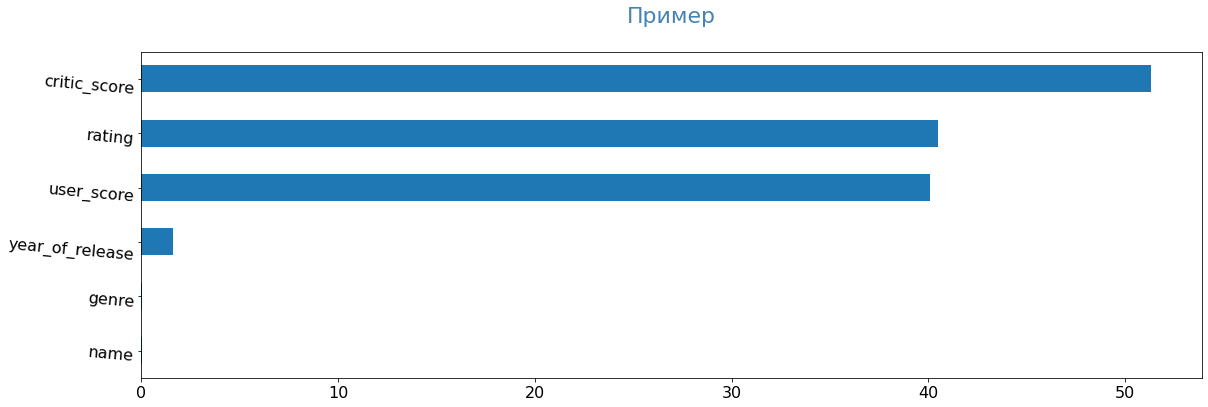

In [7]:
pass_value_barh(games_data)

<div style="border:solid steelblue 3px; padding: 20px">
<font size="4">🍕<b> Комментарий ревьюера</b></font>
<br /> 
<font size="3", color = "black">
<br /> Наглядность представления информации одна из важных составляющих работы дата-аналитика или дата-сайентиста
    
__мой график оформлен не совсем корректно, сможешь отметить, что стоило бы исправить в графике?__
  

In [8]:
#Посчитаем количество пропусков в столбцах датафрейма.
games_data.isnull().sum()

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         6701
rating             6766
dtype: int64

###### Обработаем столбец 'name':

In [9]:
#Выведем строки с пропусками в столбце.
games_data[games_data['name'].isnull()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
659,NaN,GEN,1993.0,NaN,1.78,0.53,0.00,0.08,NaN,NaN,NaN
14244,NaN,GEN,1993.0,NaN,0.00,0.00,0.03,0.00,NaN,NaN,NaN


##### Вывод:
- Две старенькие игры 1993 года выпуска - неактуальные старые данные, возможно утерялись ввиду старости, возможно сбой системы, количество крайне небольшое - просто удалим эти строки.

In [10]:
#Удалим их
games_data = games_data.dropna(subset=['name'])
#Убедимся в удалении
games_data['name'].isnull().sum()

0

###### Обработаем столбец 'year_of_release':

In [11]:
#Выведем строки с пропусками в столбце с.
games_data[games_data['year_of_release'].isnull()].head(10)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
183,Madden NFL 2004,PS2,NaN,Sports,4.26,0.26,0.01,0.71,94.0,8.5,E
377,FIFA Soccer 2004,PS2,NaN,Sports,0.59,2.36,0.04,0.51,84.0,6.4,E
456,LEGO Batman: The Videogame,Wii,NaN,Action,1.80,0.97,0.00,0.29,74.0,7.9,E10+
475,wwe Smackdown vs. Raw 2006,PS2,NaN,Fighting,1.57,1.02,0.00,0.41,NaN,NaN,NaN
609,Space Invaders,2600,NaN,Shooter,2.36,0.14,0.00,0.03,NaN,NaN,NaN
627,Rock Band,X360,NaN,Misc,1.93,0.33,0.00,0.21,92.0,8.2,T
657,Frogger's Adventures: Temple of the Frog,GBA,NaN,Adventure,2.15,0.18,0.00,0.07,73.0,tbd,E
678,LEGO Indiana Jones: The Original Adventures,Wii,NaN,Action,1.51,0.61,0.00,0.21,78.0,6.6,E10+
719,Call of Duty 3,Wii,NaN,Shooter,1.17,0.84,0.00,0.23,69.0,6.7,T
805,Rock Band,Wii,NaN,Misc,1.33,0.56,0.00,0.20,80.0,6.3,T


##### Вывод:
- Впринципе доля количества строк с пропусками в графе год небольшая,
- Таблице выше можно предположить, что это не самые свежие данные - в платформах видны PS2, X360 - их начали производить ещё в 2000 году и 2005 соответственно, так же в названиях некоторых игр можно увидеть год выпуска, однако доля количества строк с пропущенными значениями небольшая относительно датасета в целом, не будем писать регулярных выражений - просто удалим строки содержащие пропуски в этих столбцах.

In [12]:
#Удаляем.
games_data = games_data.dropna(subset=['year_of_release'])
#Приведём к типу int.
games_data['year_of_release'] = games_data['year_of_release'].astype(int)
#Убедимся в удалении.
games_data['year_of_release'].isnull().sum()

0

##### Обработаем  столбцы ''critic_score', 'user_score' , 'rating':

- Эти столбцы мы будем обрабатывать вместе с друг другом, ведь они все обозначают характеристики оценок игр, а соответственно, вероятнее всег,о связаны с друг другом. Так-же значения количества пропусков в этих столбцах схожи между собой, что дополнительно указывает на их связь.

In [13]:
#Выведем строки с пропусками в столбцах.
games_data.query('critic_score.isnull() or user_score.isnull() or rating.isnull()').head(10)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
9,Duck Hunt,NES,1984,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN
10,Nintendogs,DS,2005,Simulation,9.05,10.95,1.93,2.74,NaN,NaN,NaN
12,Pokemon Gold/Pokemon Silver,GB,1999,Role-Playing,9.00,6.18,7.20,0.71,NaN,NaN,NaN
18,Super Mario World,SNES,1990,Platform,12.78,3.75,3.54,0.55,NaN,NaN,NaN
20,Pokemon Diamond/Pokemon Pearl,DS,2006,Role-Playing,6.38,4.46,6.04,1.36,NaN,NaN,NaN
21,Super Mario Land,GB,1989,Platform,10.83,2.71,4.18,0.42,NaN,NaN,NaN
22,Super Mario Bros. 3,NES,1988,Platform,9.54,3.44,3.84,0.46,NaN,NaN,NaN


Предположение:
- Может быть есть некая взаимосвязь между годом выпуска и пропуском в этом столбце? Например в более ранних годах
культ оценки продукта был менее развит в обществе + вероятно меньше возможностей это сделать физически. отсутствие сответствующих способов для оценки.

count    8566.000000
mean     2005.867266
std         7.041302
min      1980.000000
25%      2001.000000
50%      2008.000000
75%      2011.000000
max      2016.000000
Name: year_of_release, dtype: float64

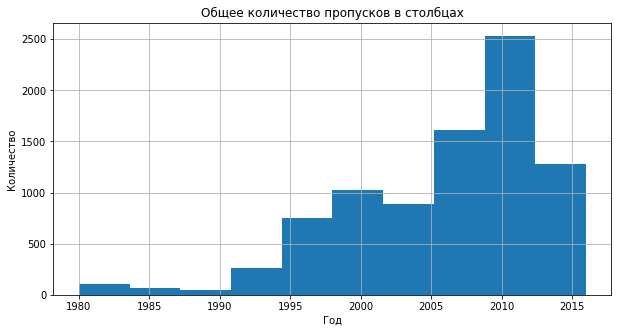

In [14]:
#Выведем описательную статистики для тех строк где в столбцах есть пропуски
display(games_data.query('critic_score.isnull() or user_score.isnull() or rating.isnull()')['year_of_release'].describe())
#Постоим гистрограммы распредедние количества пропусков по годам.
games_data.query('critic_score.isnull() or user_score.isnull() or rating.isnull()')['year_of_release'].hist(figsize=(10,5))
plt.xlabel('Год')
plt.ylabel('Количество')
plt.title('Общее количество пропусков в столбцах');

##### Вывод:
- Судя по гистрограмме распределения наибольшее количество пропусков приходится на 2010 год, однако первое предположение не отвергнуто, ведь гистрограмма показывает лишь абсолютные значения, а не соотношение пропусков в этих столбцах относительно всего количества игр в году - построим такие гистрограммы для всех столбцов отдельно(при необходимости), начнём с первого 'critic_score'.

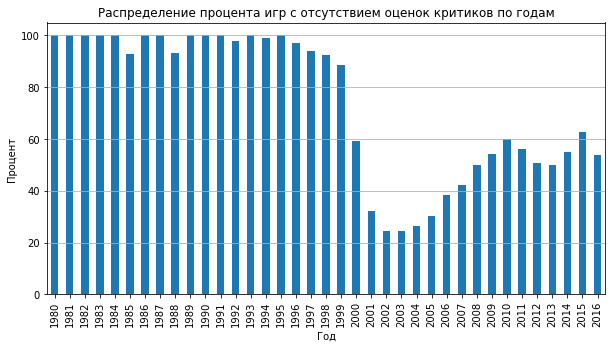

In [15]:
#Создадим переменную grouped со значениями общего количества игр и количества игр с пропусками в
#столбце с оценками критиков агрегированными по годам.
grouped = games_data.groupby('year_of_release')[['critic_score']].agg([len, lambda x: x.isnull().sum()])
#Переименуем столбцы.
grouped.columns = ['total_values', 'missing_values']
#Создадим столбец с отношением количество игр с пропусками в оценки критиков относительно общего колпчества игр.
grouped['missing_ratio'] = grouped['missing_values'] / grouped['total_values']
#Умножим его на 100 переведя значения отношения в процент игр с пропусками.
grouped['missing_ratio'] *= 100
#Создадим гистограмму.
grouped['missing_ratio'].plot(kind='bar', figsize=(10, 5))
#Назовем оси.
plt.xlabel('Год')
plt.ylabel('Процент')
#Назовём заголовок.
plt.title('Распределение процента игр с отсутствием оценок критиков по годам')
#Добавим сетку для оси y.
plt.grid(axis='y')
#Выведем гистрограмму на экран.
plt.show()

##### Вывод:
- Действительно до 2000 года процент игр с отсутствием оценок критиков был часто близок к 100%, далее в 2000 году он упал до минимальных значений в исторических данных около 20%, однако потом начал расти и вырос примерно до 50%, зафиксировался примерно на этом уровне, оставаясь довольно стабильным. Наше первое предположение о связи пропусков в столбцах, вероятнее всего, оказывается правдой, - отсутсвие оценок до 2000 года, можно объяснить отсутствием такой практики и нужды в обществе, падения в 2000 можно предположить появлением нового тренда и необходимости в оценки игр, а дальнейший рост процента игр с отсутствием оценок критиков, можно предположить, что связан с серьезным увеличением количества выпускаемых игр, децентрализации региона их выпуска, децентрализации важности игр для рынка, и увеличение процента тех игр, которые либо не интересны критикам, либо издательству не интересны оценки критиков, либо в целом аудитории не слишком важны эти игры.
- Пропуски в старых данных, пока назовём старыми те данные игр которые выпущены до 2000, не слишком важны для выполнения главной задачи - оценки характеристик влияющих на успешность игры, - ведь сам рынок с тех пор сильно изменился, для поставленной задачи впринципе эти данные мы вряд-ли будем использовать - удалим сразу эти данные, удалять строки с пропусками отдельно от удаления данных нету смысла - так как процент пропусков близок к ста, и по первой гистрограмме показывающий абсолютные числа видно, что количество игр сильно отличается в данных до 2000 и после.
- Пропуски в данных после 2000 года, возможности заполнить каким-либо значением - медианы/средней оценки за год, возможности нету, так как есть вероятность, что эти игры не слишком интересны критикам или издательствам, или же выпускаются под специфический регион, и соответственно впринципе отличаются и другими своими характеристиками - например количеством продаж. Однако объём пропусков не позволяет делать "резких" вещей, вероятно все эти пропуски взаимосвязаны и их удаление с высоким влиянием на датасет в целом может весьма исказить некоторые статистические результаты - пока оставим их и обработаем другие значения.

In [16]:
#Удалим данные до 2000 года.
games_data = games_data[games_data['year_of_release'] >= 2000]

In [17]:
##check.
games_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 14470 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             14470 non-null  object 
 1   platform         14470 non-null  object 
 2   year_of_release  14470 non-null  int64  
 3   genre            14470 non-null  object 
 4   na_sales         14470 non-null  float64
 5   eu_sales         14470 non-null  float64
 6   jp_sales         14470 non-null  float64
 7   other_sales      14470 non-null  float64
 8   critic_score     7887 non-null   float64
 9   user_score       9738 non-null   object 
 10  rating           9663 non-null   object 
dtypes: float64(5), int64(1), object(5)
memory usage: 1.3+ MB


In [18]:
#Оценим результат после удаления.
print('Количество пропусков в столбце "critic_score" после предыдущего удаления:')
print(games_data['critic_score'].isnull().sum())
print('Количество пропусков в столбце "user_score" после предыдущего удаления:')
print(games_data['user_score'].isnull().sum())
print('Количество пропусков в столбце после "rating" предыдущего удаления:')
print(games_data['rating'].isnull().sum())

Количество пропусков в столбце "critic_score" после предыдущего удаления:
6583
Количество пропусков в столбце "user_score" после предыдущего удаления:
4732
Количество пропусков в столбце после "rating" предыдущего удаления:
4807


##### Вывод:
- Удаление данных до 2000 немного снизило общее количество пропусков, однако о доли ничего не известно.

#### Отдельно обработаем значение  'tbd' в столбце с оценкой пользователей:
- Разберемся с этими значениями, может это даст понять, что делать с пропусками?

TBD - аббревиатура от английского To Be Determined (будет определено) или To Be Decided (будет решено). Используется, если какая-то информация еще не определена или решение по вопросу не принято. Акроним служит для отметки неясностей или пропусков, которые надо заполнить, в информации требований.

In [19]:
#Посчитаем и выведем количество игр со значенем "tbd" в столбце оценка пользователей.
print('Количество игр со значенем "tbd" в столбце оценка пользователей:') 
print(len(games_data.query('user_score == "tbd"')))
#Выведем 10 строк с таким значением с столбце.
games_data.query('user_score == "tbd"').head(10)

Количество игр со значенем "tbd" в столбце оценка пользователей:
2367


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
119,Zumba Fitness,Wii,2010,Sports,3.45,2.59,0.00,0.66,NaN,tbd,E
301,Namco Museum: 50th Anniversary,PS2,2005,Misc,2.08,1.35,0.00,0.54,61.0,tbd,E10+
520,Zumba Fitness 2,Wii,2011,Sports,1.51,1.03,0.00,0.27,NaN,tbd,T
645,uDraw Studio,Wii,2010,Misc,1.65,0.57,0.00,0.20,71.0,tbd,E
718,Just Dance Kids,Wii,2010,Misc,1.52,0.54,0.00,0.18,NaN,tbd,E
726,Dance Dance Revolution X2,PS2,2009,Simulation,1.09,0.85,0.00,0.28,NaN,tbd,E10+
821,The Incredibles,GBA,2004,Action,1.15,0.77,0.04,0.10,55.0,tbd,E
1047,Tetris Worlds,GBA,2001,Puzzle,1.25,0.39,0.00,0.06,65.0,tbd,E
1048,Imagine: Teacher,DS,2008,Simulation,0.70,0.82,0.00,0.19,NaN,tbd,E
1069,Personal Trainer: Math,DS,2007,Puzzle,0.48,1.12,0.00,0.08,63.0,tbd,E


- Отсутствие рейтинга или tbd означает, что издатель не захотел получать рейтинговую оценку ESRB или игра не планировалась выпускаться для региона NA, так-как столбец user_score содержит данные рейтинга ESRB, а он дейтвительны в США и Канаде, большинство игровых издателей с уважением относятся к этой организации, так-как эти рынки самые востребованые и платёжеспособные.
- Помимо ESRB, существуют и другие рейтинговые системы оценки игр: PEGI в Европе, CERO в Японии, а так же в Австралии (отличается своей непродуманностью и недружелюбием), данный рейтинг - ESRB только для США и Канады, а в нашем датасете есть данные с другими локациями, помимо США, и этим можно объяснить пропуски в значениях нашего столбца, вероятнее всего, наиболее логично сделать замену пропусков в этом столбце на значения 0 - так-как что пропуск, что TBD - это отсутствие рейтинга, а так мы приведем любое отсутствие рейтинга к общей категории - а столбец к общему типа - числовому.

In [20]:
#Заменяем пропущенные значения на 0.
games_data.loc[games_data['user_score'].isnull(), 'user_score'] = 0
#Заменяем значения 'tbd' на 0.
games_data.loc[games_data['user_score'] == 'tbd', 'user_score'] = 0
#Преобразуем столбец 'user_score' в числовой формат.
games_data['user_score'] = pd.to_numeric(games_data['user_score'], errors='coerce')
#Округляем значения.
games_data['user_score'] = games_data['user_score'].round(1)

##### Вывод:
- Мы привели все пропуски столбца 'user_score' к единому целому, теперь есть единая категория для игр без рейтинга пользователей ESRB.
- Логично было бы привести и остальные столбцы к подобному виду - вот мы и решили загвостку что делать с пропусками.

In [21]:
#Заменяем пропущенные значения на 0 в столбцах 'rating' и 'critic_score'.
games_data.loc[games_data['critic_score'].isnull(), 'critic_score'] = 0
games_data.loc[games_data['rating'].isnull(), 'rating'] = 0

In [22]:
#Оценим результат замены.
print('Количество пропусков в столбце "critic_score" после предыдущего удаления:')
print(games_data['critic_score'].isnull().sum())
print('Количество пропусков в столбце "user_score" после предыдущего удаления:')
print(games_data['user_score'].isnull().sum())
print('Количество пропусков в столбце после "rating" предыдущего удаления:')
print(games_data['rating'].isnull().sum())

Количество пропусков в столбце "critic_score" после предыдущего удаления:
0
Количество пропусков в столбце "user_score" после предыдущего удаления:
0
Количество пропусков в столбце после "rating" предыдущего удаления:
0


##### Вывод:
- Мы произвели замену всех пропусков - замену всех значений с отсутствием рейтинга - на значение 0, по сути приведя все подобные данные к единой категории.

##### Немного улучшим список категорий.
- Столбцы critic_score', 'user_score' содержат категориальные данные - первый 100-бальную оценку от критикнов(или её отсутствие в случае значений 0), второй 10-бальную оценку от пользователей(или так же её отсутствие), но таких категорий достаточно внутри столбцов из-за того, насколько точно эта оценка отображается в датасете, например: 4.75 или 91, такая точность для наших последующий исследований не нужна - а скорее будет мешать, сократить количество категорий рейтингов до 10, округлим значения столбцов до соответствующего количества символов.

<div class="alert alert-da nger">
<font size="4"><b>❌ Комментарий ревьюера</b></font>
    <br /> 
    <font size="3", color = "black">
<br /> Не стоит удалять
        
        #Удаляем строки с пропусками в столбце 'rating'.
        games_data = games_data[~(games_data['rating'].isnull())]
        
после возвращения данных с пропусками по оценке критиков, данный код снова удалит половину выборки        
        

##### Создадим столбец с суммарными продажами во всех регионах.

In [23]:
#Создадаем столбец из суммы значения всех столбцов с продажами
games_data['total_sales'] = games_data['na_sales'] + games_data['eu_sales'] + games_data['jp_sales'] + games_data['other_sales']
#Проверим, что получилось выведя несколько строк всей таблицы.
games_data.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
6,New Super Mario Bros.,DS,2006,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E,29.80
7,Wii Play,Wii,2006,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E,28.91


In [24]:
# check
games_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 14470 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             14470 non-null  object 
 1   platform         14470 non-null  object 
 2   year_of_release  14470 non-null  int64  
 3   genre            14470 non-null  object 
 4   na_sales         14470 non-null  float64
 5   eu_sales         14470 non-null  float64
 6   jp_sales         14470 non-null  float64
 7   other_sales      14470 non-null  float64
 8   critic_score     14470 non-null  float64
 9   user_score       14470 non-null  float64
 10  rating           14470 non-null  object 
 11  total_sales      14470 non-null  float64
dtypes: float64(7), int64(1), object(4)
memory usage: 1.4+ MB


#### 2.4 Обработаем дубликаты.

##### Обработаем простые дубликаты.

In [25]:
#Для начала в столбцах со строковыми значениями все значения приведем к нижнему регистру
games_data['name'] = games_data['name'].str.lower()
games_data['platform'] = games_data['platform'].str.lower()
games_data['genre'] = games_data['genre'].str.lower()
games_data['rating'] = games_data['rating'].str.lower()

In [26]:
#Обработаем простые дубликаты в столбце 'name'
print("Количество простых дубликатов в столбце name:")
print(games_data['name'].duplicated().sum())
#Выведем несколько строк таблицы с дубликатами
games_data[games_data['name'].duplicated()].sort_values(by='name').head(10)

Количество простых дубликатов в столбце name:
4769


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
3862,frozen: olaf's quest,ds,2013,platform,0.21,0.26,0.00,0.04,0.0,0.0,NaN,0.51
3120,007: quantum of solace,wii,2008,action,0.29,0.28,0.01,0.07,54.0,7.5,t,0.65
4475,007: quantum of solace,ps2,2008,action,0.17,0.00,0.00,0.26,0.0,0.0,NaN,0.43
9507,007: quantum of solace,ds,2008,action,0.11,0.01,0.00,0.01,65.0,0.0,t,0.13
1785,007: quantum of solace,ps3,2008,action,0.43,0.51,0.02,0.19,65.0,6.6,t,1.15
14658,007: quantum of solace,pc,2008,action,0.01,0.01,0.00,0.00,70.0,6.3,t,0.02
2243,007: the world is not enough,ps,2000,action,0.51,0.35,0.00,0.06,61.0,6.7,t,0.92
15656,11eyes: crossover,psp,2010,adventure,0.00,0.00,0.02,0.00,0.0,0.0,NaN,0.02
10076,18 wheeler: american pro trucker,gc,2002,racing,0.09,0.02,0.00,0.00,52.0,6.8,e,0.11
12283,187: ride or die,xb,2005,racing,0.05,0.01,0.00,0.00,51.0,6.9,m,0.06


##### Вывод:
- Дубли в наименованиях игр обоснованы тем, что представляют разные реализации одной игры для разных платформ, что несёт за собой для каждой платформы свои уникальные показатели.

##### Обработаем неполные  дубликаты.

In [27]:
#Обработаем неполные дубликаты поиском похожих значений записанных по разному в столбцах не являющемися числовыми
#и без столбца 'name' - так как там слишком много уникальных значению
#и его не обработать таким образом вручную - его мы обработаем позже отдельно.
for name in games_data.columns:
    if games_data[name].dtype != 'float64' and name != 'name':
        print(F"Количество уникальных значений в столбце '{name}':")
        print(len(games_data[name].sort_values().unique()))
        print(F"Список уникальных значений в столбце '{name}':")
        print(games_data[name].sort_values().unique())
        print()

Количество уникальных значений в столбце 'platform':
20
Список уникальных значений в столбце 'platform':
['3ds' 'dc' 'ds' 'gb' 'gba' 'gc' 'n64' 'pc' 'ps' 'ps2' 'ps3' 'ps4' 'psp'
 'psv' 'wii' 'wiiu' 'ws' 'x360' 'xb' 'xone']

Количество уникальных значений в столбце 'year_of_release':
17
Список уникальных значений в столбце 'year_of_release':
[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016]

Количество уникальных значений в столбце 'genre':
12
Список уникальных значений в столбце 'genre':
['action' 'adventure' 'fighting' 'misc' 'platform' 'puzzle' 'racing'
 'role-playing' 'shooter' 'simulation' 'sports' 'strategy']

Количество уникальных значений в столбце 'rating':
8
Список уникальных значений в столбце 'rating':
['ao' 'e' 'e10+' 'ec' 'm' 'rp' 't' nan]



##### Вывод:
- Неполные дубликаты в этих столбцах отсутствуют.

###### Поиск дубликатов в столбце 'name':
- Мы привели столбец 'name' к нижнему регистру на предыдщих этапах, таким образом приведя все неполные дубликаты, связанные с подобной ошибкой, к виду обычных дубликатов. Но мы выяснили, что обычные дубликаты в этом столбце - это нормально - так как игры выпускаются под разные платформы, однако в датафрейфе могут быть дубликаты строк, там где значения имени является дубликатом и ещё несколько основных категориальных значений так-же являются дубликтами такого-же набора, проверим датафрейм на подобное:

In [28]:
#Поищем совпадения
display(games_data[games_data.duplicated(['name', 'platform', 'year_of_release'], keep='first')])

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
16230,madden nfl 13,ps3,2012,sports,0.0,0.01,0.0,0.0,83.0,5.5,e,0.01


In [29]:
#Удалим 
games_data = games_data.drop(index=16230)

##### Вывод:
- Был обнаружен и устранён один дубликат.

#### Вывод раздела:
- Мы провели оценку и обработку данных. 
- Основная сложность была правильным подходам к устранению пропусков. 
- Теперь данные стали куда более качественным и мы готовы переходить к более основным задачам.

#### Общий вывод:
Качество данных изначально было не самим лучшим - пришлось сделать несколько обработок, мы обработали типы - с ними в целом все было хорошо, далее мы обработали пропуски - их было не мало, много данных пришлось удалить, так же мы добавили столбец с информацией об общем количестве продаж во всей регионах - на выходе мы получили получили гораздо более качественные и "правдивые" данные, время приступать к исследовательскому анализу и далее проверять гипотезы, уже на основе "хороших" данных.

###  Шаг 3. Исследовательский анализ данных

#### 3.1 Определение степени важности всех периодов - годов выпуска игр. Посмотрите, сколько игр выпускалось в разные годы. Важны ли данные за все периоды?
- На предыдущем этапе мы удалили данные до 2000, теперь определим важность оставшихся периодов в данных.

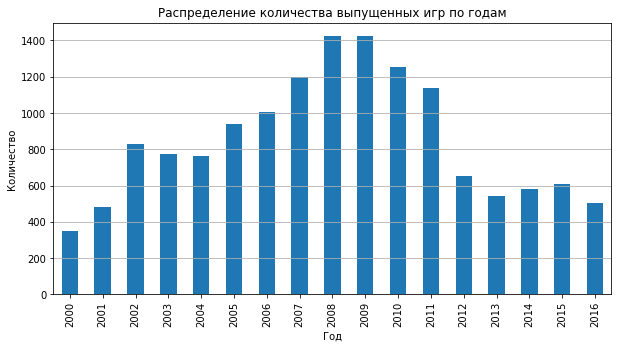

In [30]:
#Построим сводную таблицу методом pivot_table, где количество игр будет агрегированно по годам.
#Далее построим гистрограмму распределение из этой таблицы.
games_data.pivot_table(
                       index='year_of_release', 
                       values='name', 
                       aggfunc='count'
                       ).reset_index().plot(
                                            x='year_of_release', 
                                            y='name', 
                                            kind='bar', 
                                            figsize=(10, 5), 
                                            legend=False
                                            )

#Назовем оси.
plt.xlabel('Год')
plt.ylabel('Количество')
#Назовём заголовок.
plt.title('Распределение количества выпущенных игр по годам')
#Добавим сетку для оси y.
plt.grid(axis='y')
#Выведем гистрограмму на экран.
plt.show()

##### Вывод:
- С 2002 года по 2011 количество выпускаемых игр выросло относительно предыдущих периодов и оставалось стабильно на уровне примерно 600 игр в год - видимо рынок нашёл некий баланс относительно абстоятельств, в 2012 году количество выпускаемых игр снизилось примерно вдвоем и далее по 2016 год оставалось стабильным - видимо абстоятельства на рынке немного изменились в 2011 по 2012, однако почти сразу опять нашелся баланс и рынок стабильно схож на периоде с 2012 по 2016 года.
- В целом количество выпускаемых игр в период с 2001 по 2011 года достаточно для информативности, этот период стоит оставить для проверки вопроса касающегося динамике продаж по платформам, после этого стоит удалить данный период с датасета, 2000 год - удаляем сразу, а так в целом, с 2012 гожа рынок начал отличаться от предыдущих периодов, и снова поймал баланс уже с новыми характеристиками, и держит его вплоть до актуальных данных 2016 года, - значит именно в этот период есть наиболее важные и потенциально "правдивые" взаимосвязи, исходя из этого можно говорить о том, что это наиболее актуальный период. Однако игровая индустрия один из наиболее динамичных рынков в мире, поэтому и период трендов весьма изменчив - что касается того периода, который стоит взять для решения наших задач - то это вероятнее всего период полного 2015 года и неполного(насколько есть в данных) 2016 - при наличии общих трендов из предыдущих периодов - они так же сохранятся в этом периоде, при появлении новых они будут видны и актуальны, при этом объе данных будет достаточно высок и полон, хотя при этом и отображающим актуальную информацию.

In [31]:
#Удалим данные за 2000 год.
games_data = games_data[games_data['year_of_release'] > 2000]

#### 3.2 Оценим динамику изменения продаж по платформам. Выберем платформы с наибольшими суммарными продажами и постройте распределение по годам. Ответим на вопрос: 
- За какой характерный срок появляются новые и исчезают старые платформы?

In [32]:
#Определим топ платформ по продажам.
#Построим сводную таблицу с общими продажами по платформам.
sales_top = games_data.pivot_table(
                                   index='platform',
                                   values='total_sales', 
                                   aggfunc='sum'
                                   ).reset_index(#Сбросим индексы, чтобы названия платформ стали столбцом.
                                                 ).sort_values(#Отсортируем по убыванию.
                                                               by='total_sales',
                                                               ascending=False
                                                               ).reset_index(#Снова сбросим индексы, чтобы привести их последовательность в нормальный порядок(0,1,2,3 и т.д)
                                                                            ).drop(#Удалим возникший из-за действия выше столбец с предыдущими индексами.
                                                                                   'index',
                                                                                    axis=1
                                                                                   )
#Запишем сумму всех продаж строк ниже 10 по индексу включительно в значение столбеца 'total_sales' по этому индексу
sales_top.loc[10, 'total_sales'] = sales_top.loc[10, 'total_sales'].sum()
#Назовём эту строку 'other'
sales_top.loc[10, 'platform'] = 'others'
#Удалим строки ниже
sales_top = sales_top[0:11]
#Вычислим процент продаж для каждого жанра
sales_top['percent'] = (sales_top['total_sales'] / sales_top['total_sales'].sum()) * 100
#Поверим полученную таблицу топ 10 по продажам платформы, продажи остальных платформ в общей строке - 'others'
display(sales_top)

,platform,total_sales,percent
0,ps2,1194.39,18.642449
1,x360,961.24,15.003364
2,ps3,931.33,14.536518
3,wii,891.18,13.909843
4,ds,802.76,12.529753
5,ps4,314.14,4.903205
6,gba,312.81,4.882446
7,psp,289.53,4.519084
8,3ds,257.81,4.023987
9,xb,250.58,3.911139


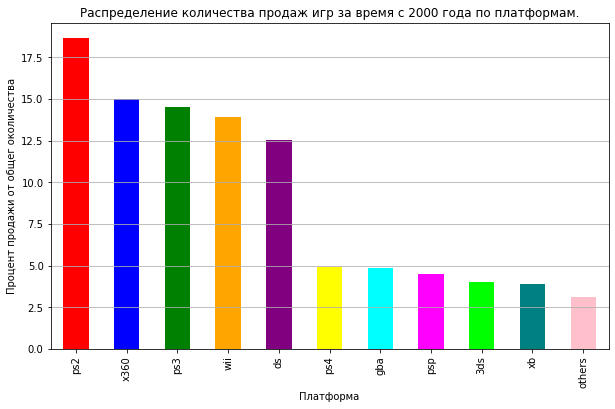

In [33]:
#Визуализируем таблицу построив гистрограмму распределения.
#Создадим фигуру, зададим размер.
sales_top.plot(
               x='platform', 
               y='percent', 
               kind='bar', 
               figsize=(10, 6), 
               legend=False,
               color = ['red', #Цвета передадим вручную списпком, так-как иначе некоторые сегменты имеют одинаковый окрас
                        'blue',
                        'green', 
                        'orange', 
                        'purple', 
                        'yellow', 
                        'cyan', 
                        'magenta', 
                        'lime', 
                        'teal', 
                        'pink'] 

               )

#Назовем оси.
plt.xlabel('Платформа')
plt.ylabel('Процент продажи от общег околичества')
#Назовём заголовок.
plt.title('Распределение количества продаж игр за время с 2000 года по платформам.', fontsize=12)
#Добавим сетку для оси y.
plt.grid(axis='y')
#Выведем гистрограмму на экран.
plt.show()

##### Выводы:
- Распределение по платформам сильно отличается.
- Наиболее популярны консоли, к примеру: PS2, X360, PS3.

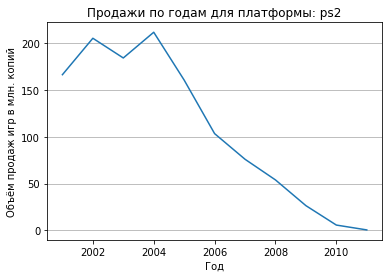

Срок жизни платформы в годах: 10


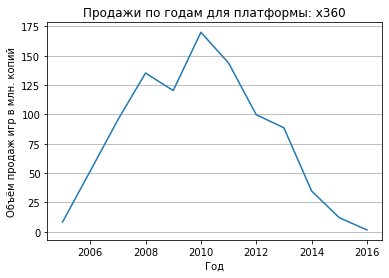

Срок жизни платформы в годах: 11


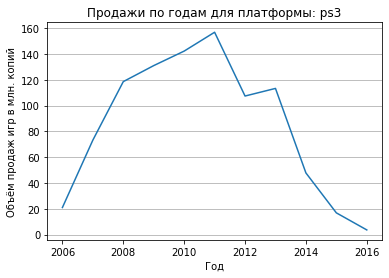

Срок жизни платформы в годах: 10


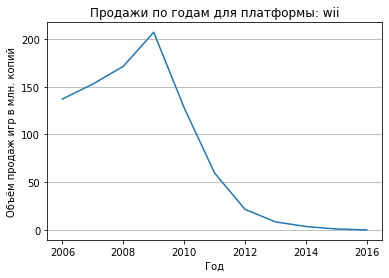

Срок жизни платформы в годах: 10


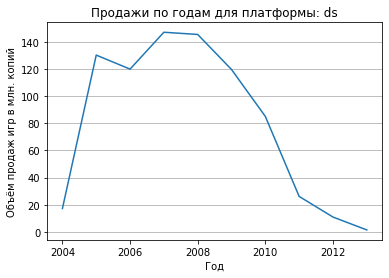

Срок жизни платформы в годах: 9


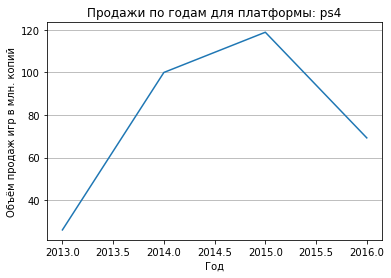

Срок жизни платформы в годах: 3


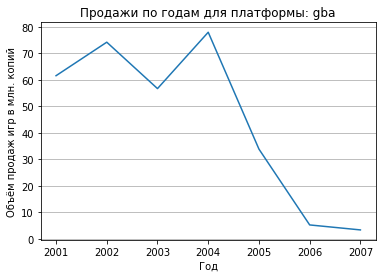

Срок жизни платформы в годах: 6


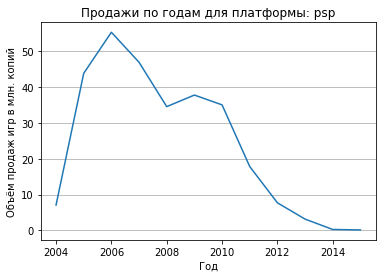

Срок жизни платформы в годах: 11


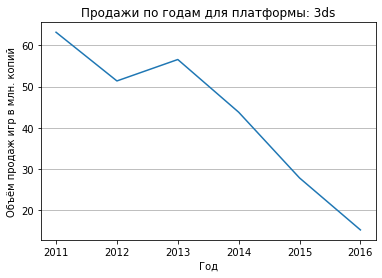

Срок жизни платформы в годах: 5


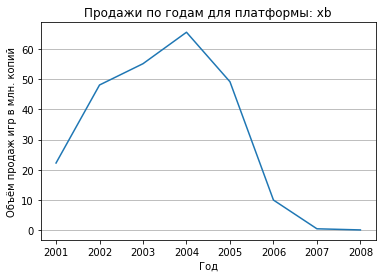

Срок жизни платформы в годах: 7


In [34]:
#Создадим пустые список для записи туда значений.
total = []
years_realized = []
#Напишем цикл, которы будет строить сводные таблицы для каждой платформы 
#агрегированные по годам со значениями количества продаж.
for k in sales_top.loc[0:9, 'platform']:
    sales_platforms = games_data[games_data['platform'] == k].pivot_table(
                                                                          index='year_of_release', 
                                                                          values='total_sales', 
                                                                          aggfunc='sum'
                                                                          ) 
    plt.plot(sales_platforms.index, sales_platforms['total_sales'], label=k)
    # Добавление подписей осей
    plt.xlabel('Год')
    plt.ylabel('Объём продаж игр в млн. копий')
    #Добавим сетку для оси y.
    plt.grid(axis='y')
    # Заголовок графика
    plt.title(f'Продажи по годам для платформы: {k}')
    # Показать график
    plt.show()
    #Вывыдем для каждой платформы срок её жизни
    years_of_platform_live = sales_platforms.index.max() - sales_platforms.index.min()
    print(f'Срок жизни платформы в годах: {years_of_platform_live}')
    #Добавим этот срок в список total для последующего анализа
    total.append(years_of_platform_live)
    years_realized.append(sales_platforms.index.min())
plt.show()

In [35]:
#Преобразуем списки в в Series для подсчёта статистики.
total = pd.Series(total)
years_realized = pd.Series(years_realized)
#В series 'years_realized' отнимем первое значения - превратим это в современный календарь, 
#только здесь каждый год теперь это отсчёт лет с момента выхода первой платформы.
years_realized -= years_realized[0]
#Покажем статистику.
print(f'Медиана лет жизни платформы из топ 10 по продажам с 2000 года: \n{total.median()} \nСреднее количество лет жизни: \n{total.mean()}')
print()
print(f'Медиана срока выхода новой платформы из топ 10 по продажам с 2000 года: \n{years_realized.median()} \nСреднее: \n{years_realized.mean()}')

Медиана лет жизни платформы из топ 10 по продажам с 2000 года: 
9.5 
Среднее количество лет жизни: 
8.2

Медиана срока выхода новой платформы из топ 10 по продажам с 2000 года: 
3.5 
Среднее: 
4.2


##### Выводы:
- Новые платформы появляются в среднем примерно примерно каждые 4 года.
- Что касается исчезновения старых - то тут вопрос, что считать исчезновением:
   - Среднее количество лет жизни платформы около 8, это обозначает, что по истечению этого срока разработчики полностью перестают выпускать под неё игры и платформа теряет поддержку, производство вероятнее заканчивается раньше - полагаю с выходом новой, то есть этот срок обозначает полный конец поддержки платформы.
   - Однако если посмотреть на графики продаж игр по платфорам - то можно заметить у всех похожую структуру, сначала идёт подъём, далее некий максимальный пик - эстремума на графике - затем происходит падение без подъёмов. Этот пик, скорее всего, в большинстве случаев(за исключением как минимум ПК) обозначает выход новой интересной платформ и соответственно снижение интереса к предыдущий платформе, процесс "смерти" каждой платформы точно начинает с этого экстремума, значит можно сказать, что начало исчезновения платформы - это выход новой - примерно каждый 3 года, эта информация полезна для бизнеса с точки определения стратегий развития и превентивного переключения с платформы после "начала её конца".

#### 3.3 Сделаем новый датасет только с актуальными данными после 2015 включительно:
- Выбрав актуальный период для решения остальных задач, как планировали в выводах пункта 3.1

In [36]:
#Удалим данные до 2011 года включительно в основном датасете:
games_data = games_data[games_data['year_of_release'] > 2011]
#Создадим новый датасет только с актуальными данными после 2015 включительно:
actual_games_data = games_data[games_data['year_of_release'] >= 2015]

#### 3.4 Определим актуальные лидирующие по продажам платформы.
- Так-же определим стадию тренда количества продаж платформ: рост, падение.

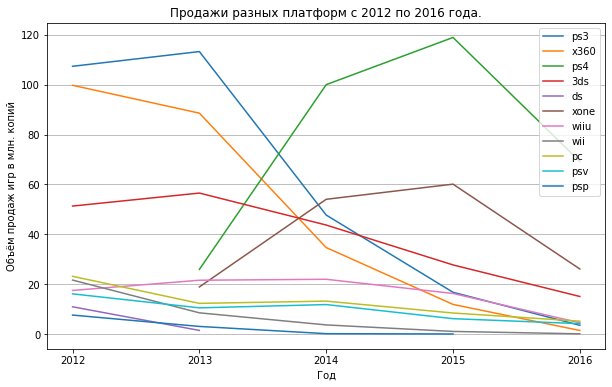

In [37]:
#Создадим пустой график.
plt.figure(figsize=(10, 6))
#Напишем цикл, который будет строить продажи по годам для каждой платформы на одном графике.
for k in games_data['platform'].unique():
    sales_platforms = games_data[games_data['platform'] == k].pivot_table(
                                                                          index='year_of_release', 
                                                                          values='total_sales', 
                                                                          aggfunc='sum'
                                                                          )
    plt.plot(sales_platforms.index, sales_platforms['total_sales'], label=k)
#Добавим подписи осей.
plt.xlabel('Год')
plt.ylabel('Объём продаж игр в млн. копий')
#Добавим сетку для оси y.
plt.grid(axis='y')
#Добавим заголовок графика.
plt.title('Продажи разных платформ с 2012 по 2016 года.')
#Добавим легенды.
plt.legend()
#Отобразим только целые числа по оси x.
plt.locator_params(axis='x', integer=True)
#Показать график.
plt.show()

##### Вывод:
- На момент 2016 года самыми популярными платформами остаются PS4 и XboxOne, можно заметить видно, некий спад в 2016 году, но это, вероятнее всего, связано лишь с тем, что данные за 2016 год не полные, поэтому судить о тренде по ним нельзя, а вот с 2013 по 2015 года, можно сказать точно, что есть некая тендеция роста продаж для этих платформ.
- На стабильном уровне находятся продажи для PC и PSV 
- Хоть 3DS и WiiU обгоняют PSV по объему продаж однако разница не велика, а вот тренд отличается - продажа игр на PSV остаётся более стабильно, а вот первые две падают - риски для бизнеса относительно игр для таких платформ отображают вопросы:
  - Остановится ли их падение? 
  - Где? 
  - Или может быть они "уйдут на покой"?
- Итог для бизнеса:
   - Лучшими играми для продаж являются ориентированные на платформы PS4 и XboxOne.
   - Менее важными по объему для бизнеса, однако стабильными и создающими диверсификацию источников прибыли могут стать игры ориентированные на платформы PC и PSV.

#### 3.5 Оценим глобальные  продажи в разбивке по платформам взяв наиболее актуальный период.

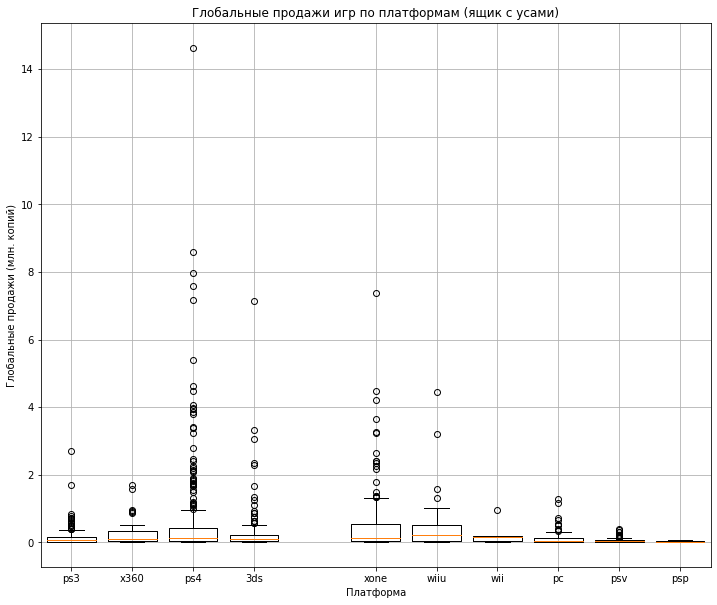

In [38]:
#Создаем пустую фигуру для графика.
plt.figure(figsize=(12, 10))
#Пишем цикл для итерации по уникальным платформам и построение ящика с усами для каждой платформы на одном графике.
for name_platform in actual_games_data['platform'].unique():
    #Фильтруем данные платформ, выводим столбец продаж.
    platform_sales = actual_games_data[actual_games_data['platform'] == name_platform]['total_sales']
    #Строим ящики с усами для платформ.
    plt.boxplot(
                platform_sales, #Значения это числа продаж
                labels=[name_platform], #Имена это список уникальных значений платформ
                positions=[games_data['platform'].unique().tolist().index(name_platform) + 1],#Создаем список для расположения позиций:
                widths=0.8 #Настроим размер-ширину каждого ящика
               )                                                                             #уникальные значения преобразуем в список,
                                                                                              #возвращаем его индексы,
                                                                                              #прибавляем 1 так-как индексы начинаются с нуля

#Настроим метки заголовка и осей
plt.title('Глобальные продажи игр по платформам (ящик с усами)')
plt.xlabel('Платформа')
plt.ylabel('Глобальные продажи (млн. копий)')
plt.grid(True)
#Выведем график
plt.show()

- Из-за чрезмерных значений выбросов на этом графике видны только они, и совсем не видны медиана и 75% квантиль. Для более обоснованных выводов прежде чем переходить к ним - построим ещё один такой график - только без отображения выбросов и с ограничем отображения по оси y.

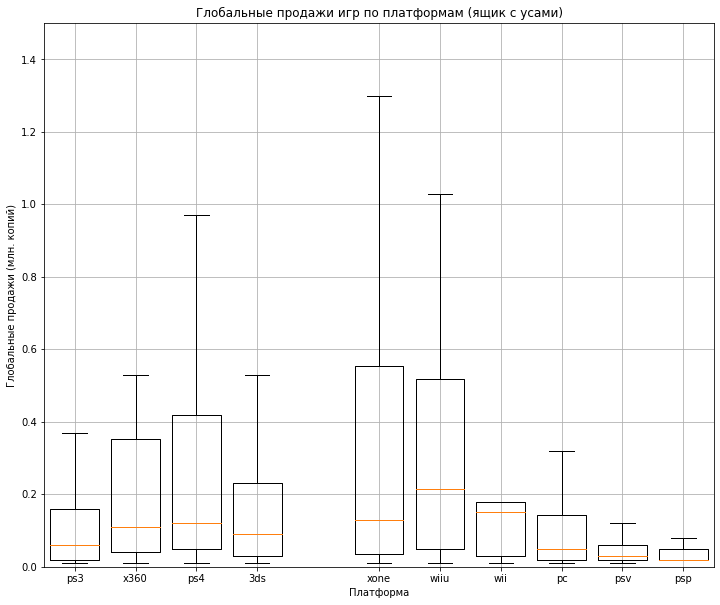

In [39]:
#Строим
plt.figure(figsize=(12, 10),)
for name_platform in actual_games_data['platform'].unique():
    platform_sales = actual_games_data[actual_games_data['platform'] == name_platform]['total_sales']
    plt.boxplot(
                platform_sales, 
                labels=[name_platform],
                positions=[games_data['platform'].unique().tolist().index(name_platform) + 1],
                widths=0.8,
                showfliers=False
               )                                                                             
plt.title('Глобальные продажи игр по платформам (ящик с усами)')
plt.xlabel('Платформа')
plt.ylabel('Глобальные продажи (млн. копий)')
plt.grid(True)
plt.ylim(0, 1.5)
plt.show()

<div class="alert alert-da nger">
<font size="4"><b>❌ Комментарий ревьюера</b></font>
    <br /> 
    <font size="3", color = "black">
<br />        
К сожалению, на этом графике видны только выбросы, и совсем не видны медиана и 75% квантиль. Для более обоснованных выводов cтоит добавить второй вид, с другим масштабом по оси y, где будет отображена только нижняя часть boxplot-ов
       
Оба вида важны, т.к. выбросы — это наши звезды, которые приносят максимум выручки
        


#### Вывод:
- Продажи внутри платформ разнятся, есть выбросы.
- Медианы между большинством платформ схожы.
- Больше всего выбросов у PS3, X360, PS4.
- Наибольшее число продаж сейчас на платформе XOne, далее идет PS4 и WIIU - все это наиболее свежие платформы на период данных.
- Итоговый вывод для бизнеса:
   - Разные игры могут продаваться совершенно по разному, и чем популярнее платформа тем больше это может ошушаться. Продажи некоторых игр могут быть выбросами, а соответственно сильно отличаться от общего диапазона продаж всех игр, и такие выбросы случаются часто, - поэтому при выборе игр для продаж необходимо учитывать разные факторы, потенциально влияющее на количество продаж в будущем: 
      - Чтобы как минимум не иметь в продаже лишь игры, которые будут продаваться низко.
      - Как максимум создать более эффективный портфель игр для продажи, превосходящий просто средний диапазон продаж игр по рынку.
    - Сейчас в тренде наиболее свежие платформы - консоли: XOne, PS4 и WIIU.

#### 3.5 Определение степени влияния на продажи внутри одной популярной платформы на выбор отзывов пользователей и критиков. Построене диаграммы рассеяния и подсчет корреляций между отзывами и продажами. Формулирование выводов.

##### Выберем две платформы XONE и PS4 для оценки взаимосвязей.
- Она имеет историю продаж(около 3 лет).
- Сейчас это аиболее актуальные и популярные платформы относительно продаж игр.
- Так-же это две платформы - конкуренты, выводы, сделанные на основе расчетов по нескольким таким платформам будут надёжнее.

In [40]:
#Сохраним в переменные данные для выбранной платформы.
#Устраним заглушки - 0.
ps4_critic_games_data = actual_games_data.query('(platform == "ps4") & (critic_score != 0)')
ps4_user_games_data = actual_games_data.query('(platform == "ps4") & (user_score != 0)')                                                            
xone_critic_games_data = actual_games_data.query('(platform == "xone") & (critic_score != 0)')
xone_user_games_data = actual_games_data.query('(platform == "xone") & (user_score != 0)')

<div class="alert alert-da nger">
<font size="4"><b>❌ Комментарий ревьюера в2</b></font>
    <br /> 
    <font size="3", color = "black">
<br />
    
Срез стоит подправить. Имеются строки, где нет оценки критиков, но есть оценка игроков. Срезая все сразу, мы теряем эти строки. 
        
        ps4_games_data = actual_games_data.query('(platform == "ps4") & (user_score != 0) & (critic_score != 0)')
        xone_games_data = actual_games_data.query('(platform == "xone") & (user_score != 0) & (critic_score != 0)')
        
</div>

##### Обработаем рейтинги критиков для xone.

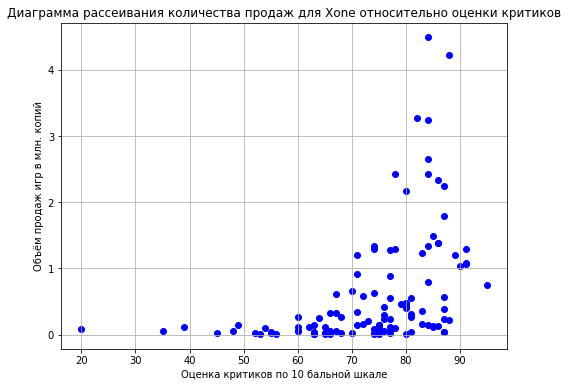

In [41]:
#Построим диаграмму рассеивания.
#Создадим фигуру, установим размер.
plt.figure(figsize=(8, 6))
#Строим и настраиваем саму диаграмму.
plt.scatter(y=xone_critic_games_data['total_sales'], x=xone_critic_games_data['critic_score'], color='blue', marker='o') 
#Назовём заголовок графика.
plt.title('Диаграмма рассеивания количества продаж для Xone относительно оценки критиков') 
#Подпишем оси.
plt.xlabel('Оценка критиков по 10 бальной шкале')  
plt.ylabel('Объём продаж игр в млн. копий')
#Включим сетку.
plt.grid(True) 
#Отобразим.
plt.show() 

In [42]:
print('Корреляция объема продаж игр с оценкой критиков:')
print(xone_critic_games_data['total_sales'].corr(xone_critic_games_data['critic_score']))

Корреляция объема продаж игр с оценкой критиков:
0.430888745821368


##### Вывод:
- Корреляция объема продаж игр с оценкой критиков составляет примерно 0.43 - такой коэффициент указывает на положительную корреляцию между этими двумя переменными. Таким образом, игры, получившие более высокие оценки критиков, склонны иметь более высокие объемы продаж, но эта взаимосвязь не настолько статистически сильна.
- На диаграмме рассеивания некая взаимосвязь между этими характеристиками прослеживается, видно тренд увеличения продаж, однако распределение весьма случайно.

##### Обработаем рейтинги пользователей.

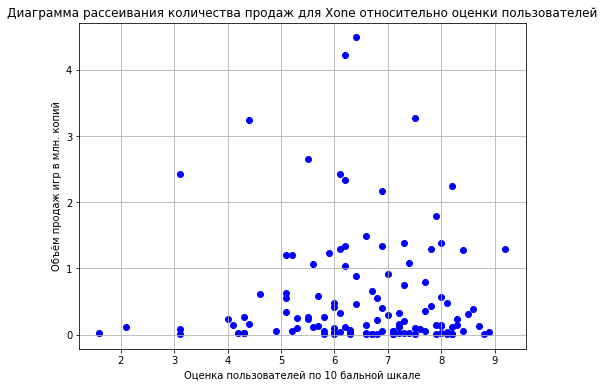

In [43]:
#Построение диаграмму рассеивания.
#Создадим фигуру, установим размер.
plt.figure(figsize=(8, 6))
#Строим и настраиваем саму диаграмму.
plt.scatter(y=xone_user_games_data['total_sales'], x=xone_user_games_data['user_score'], color='blue', marker='o') 
#Назовём заголовок графика.
plt.title('Диаграмма рассеивания количества продаж для Xone относительно оценки пользователей') 
#Подпишем оси.
plt.xlabel('Оценка пользователей по 10 бальной шкале')  
plt.ylabel('Объём продаж игр в млн. копий')
#Включим сетку.
plt.grid(True) 
#Отобразим.
plt.show() 

In [44]:
print('Корреляция объема продаж игр с оценкой пользователей:')
print(xone_user_games_data['total_sales'].corr(xone_user_games_data['user_score']))

Корреляция объема продаж игр с оценкой пользователей:
-0.04146733387366271


##### Вывод:
- Корреляция объема продаж игр с оценкой пользователей составляет примерно -0.04 или около 0. Этот коэффициент указывает на отсутствие значимых взаимосвязей между параметрами.
- По диаграмме рассеивания связь так-же неочевидна - распределение случайно.

#### Соотнесем выводы с продажами игр на ps4.

##### Обработаем рейтинги критиков.

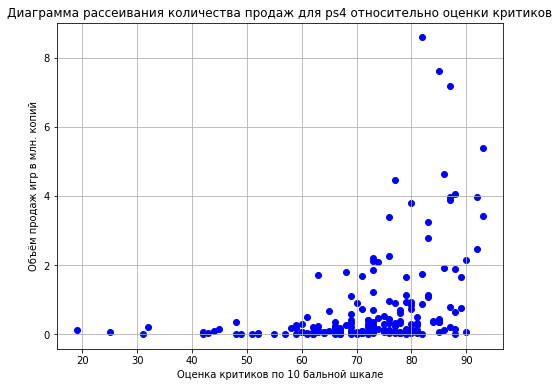

In [45]:
plt.figure(figsize=(8, 6))
plt.scatter(y=ps4_critic_games_data['total_sales'], x=ps4_critic_games_data['critic_score'], color='blue', marker='o') 
plt.title('Диаграмма рассеивания количества продаж для ps4 относительно оценки критиков') 
plt.xlabel('Оценка критиков по 10 бальной шкале')  
plt.ylabel('Объём продаж игр в млн. копий')
plt.grid(True) 
plt.show() 

In [46]:
print('Корреляция объема продаж игр с оценкой критиков:')
print(ps4_critic_games_data['total_sales'].corr(ps4_critic_games_data['critic_score']))

Корреляция объема продаж игр с оценкой критиков:
0.3928485555130601


##### Обработаем рейтинги пользователей.

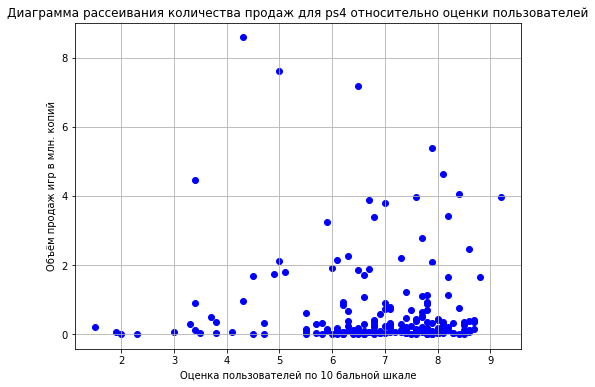

In [47]:
plt.figure(figsize=(8, 6))
plt.scatter(y=ps4_user_games_data['total_sales'], x=ps4_user_games_data['user_score'], color='blue', marker='o') 
plt.title('Диаграмма рассеивания количества продаж для ps4 относительно оценки пользователей') 
plt.xlabel('Оценка пользователей по 10 бальной шкале')  
plt.ylabel('Объём продаж игр в млн. копий')
plt.grid(True) 
plt.show() 

In [48]:
print('Корреляция объема продаж игр с оценкой пользователей:')
print(ps4_user_games_data['total_sales'].corr(ps4_user_games_data['user_score']))

Корреляция объема продаж игр с оценкой пользователей:
-0.05973845712638215


##### Вывод:
- Все показатели взаимосвязей практически не отличаются для выбранных платформ.

##### Итог:
- Оценка критиков имеет большее влияние на вероятность увеличения объема продаж чем оценка пользователей, однако в целом обе эти оценки не дают достаточно точного прогноза относительно параметры количества продаж - прогнозирование стратегий лишь на их основе в целом - слишком рискованно и "неблагодарно", разницы между показателями взаимосвязей этих параметров относительно платформ нету - влияние везде весьма идентично.

#### 3.7  Анализ общего распределения игр по жанрам. Ответ на вопросы: 
- Что можно сказать о самых прибыльных жанрах? 
- Выделяются ли жанры с высокими и низкими продажами?

##### Построим  диаграмму размаха для распределения по жанрам с отображением выбросов.

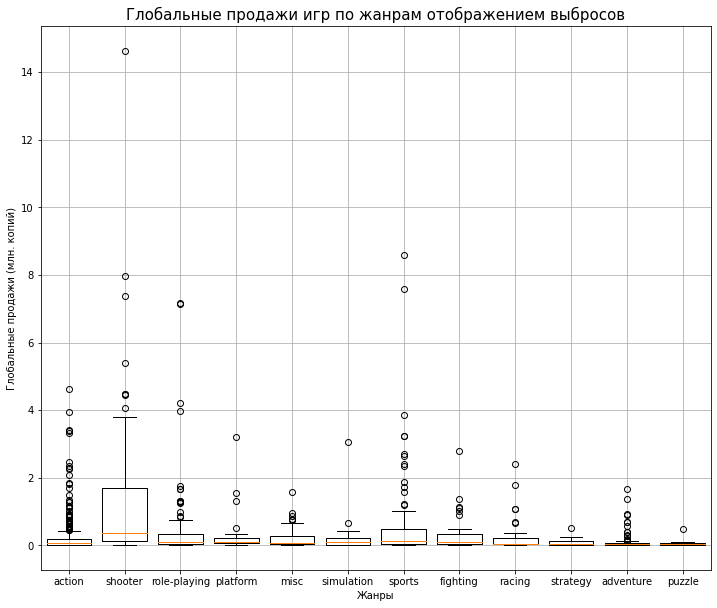

In [49]:
plt.figure(figsize=(12, 10))
for name_platform in actual_games_data['genre'].unique():
    platform_sales = actual_games_data[actual_games_data['genre'] == name_platform]['total_sales']
    plt.boxplot(
                platform_sales, 
                labels=[name_platform], 
                positions=[games_data['genre'].unique().tolist().index(name_platform) + 1],
                widths=0.8 
               )                                                                             
plt.title('Глобальные продажи игр по жанрам отображением выбросов', fontsize=15)
plt.xlabel('Жанры')
plt.ylabel('Глобальные продажи (млн. копий)')
plt.grid(True)
plt.show()

##### без отображением выбросов.

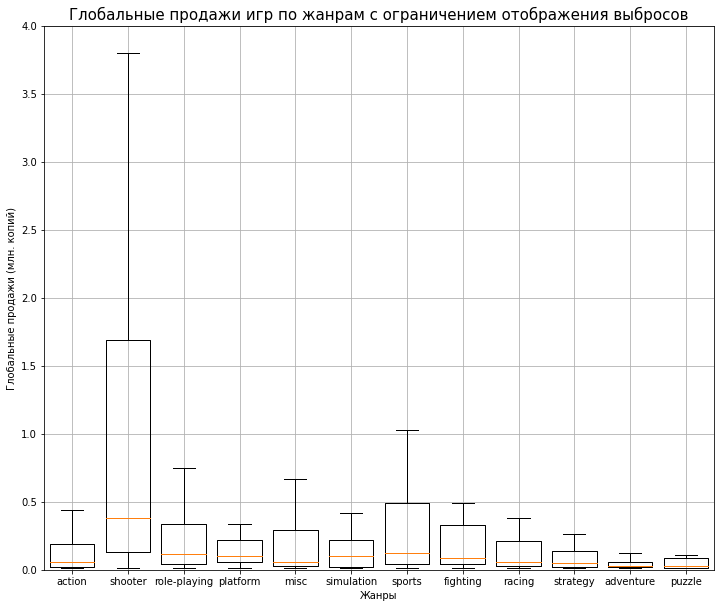

In [50]:
plt.figure(figsize=(12, 10))
for name_platform in actual_games_data['genre'].unique():
    platform_sales = actual_games_data[actual_games_data['genre'] == name_platform]['total_sales']
    plt.boxplot(
                platform_sales, 
                labels=[name_platform], 
                positions=[games_data['genre'].unique().tolist().index(name_platform) + 1],
                widths=0.8,
                showfliers=False,
               )                                                                             
plt.title('Глобальные продажи игр по жанрам с ограничением отображения выбросов', fontsize=15)
plt.xlabel('Жанры')
plt.ylabel('Глобальные продажи (млн. копий)')
plt.ylim(0, 4)
plt.grid(True)
plt.show()

##### Вывод:
- Распределение во всех жанрах имеет большое количество выбросов.
- Наибольшая медиана и размах у жанра shooter - этот жанр является наиболее стабильно популярным и сильно выделяется среди остальных.
- Далее с все еще явным по всем этим характеристиками идёт жанр sports
- Затем идут три схожих по диапазонах, медианам и распределению жанра: role-playing, misc. fighting.

In [51]:
actual_games_data['genre'].unique()

array(['shooter', 'sports', 'role-playing', 'action', 'platform',
       'simulation', 'fighting', 'racing', 'adventure', 'misc',
       'strategy', 'puzzle'], dtype=object)

In [52]:
# check
actual_games_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1108 entries, 31 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             1108 non-null   object 
 1   platform         1108 non-null   object 
 2   year_of_release  1108 non-null   int64  
 3   genre            1108 non-null   object 
 4   na_sales         1108 non-null   float64
 5   eu_sales         1108 non-null   float64
 6   jp_sales         1108 non-null   float64
 7   other_sales      1108 non-null   float64
 8   critic_score     1108 non-null   float64
 9   user_score       1108 non-null   float64
 10  rating           595 non-null    object 
 11  total_sales      1108 non-null   float64
dtypes: float64(7), int64(1), object(4)
memory usage: 112.5+ KB


### Шаг 4. Составление портрета пользователя по регионам.

#### Самые популярные  жанры (топ-5).

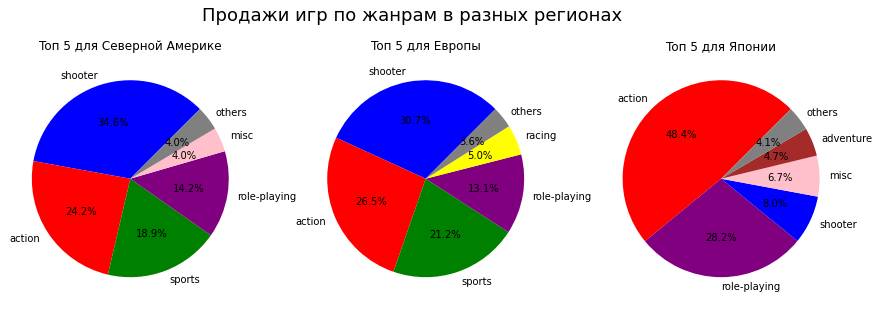

In [53]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Продажи игр по жанрам в разных регионах', fontsize=18)

color_dict = { #словарь цветов для категорий жанров
              'shooter': 'blue',
              'sports': 'green',
              'role-playing': 'purple',
              'action': 'red',
              'platform': 'orange',
              'simulation': 'cyan',
              'fighting': 'magenta',
              'racing': 'yellow',
              'adventure': 'brown',
              'misc': 'pink',
              'strategy': 'lime',
              'puzzle': 'teal'
              }

for i, k in enumerate(['na_sales', 'eu_sales', 'jp_sales']):    
    #Построим сводную таблицу топ жанров по продажам по регионам
    sales_top_5 = actual_games_data.pivot_table(
                                                index='genre',
                                                values=k, 
                                                aggfunc='sum'
                                                ).reset_index(#Сбросим индексы, чтобы названия платформ стали столбцом.
                                                     ).sort_values(#Отсортируем по убыванию.
                                                                   by=k,
                                                                   ascending=False
                                                                   ).reset_index(#Снова сбросим индексы, чтобы привести их последовательность в нормальный порядок(0,1,2,3 и т.д)
                                                                                ).drop(#Удалим возникший из-за действия выше столбец с предыдущими индексами.
                                                                                       'index',
                                                                                        axis=1
                                                                                       )
    #Запишем сумму всех продаж строк ниже 10 по индексу включительно в значение столбеца 'total_sales' по этому индексу
    sales_top_5.loc[5, k] = sales_top_5.loc[5, k].sum()
    #Назовём эту строку 'other'
    sales_top_5.loc[5, 'genre'] = 'others'
    #Удалим строки ниже
    sales_top_5 = sales_top_5[0:6]
    #Добавляем на график круговую диаграмму
    axs[i].pie(
               sales_top_5[k], 
               labels=sales_top_5['genre'], 
               autopct='%1.1f%%', 
               startangle=45, 
               colors=[color_dict.get(genre, 'gray') for genre in sales_top_5['genre']]
                )
    if k == 'na_sales':
        region = 'Северной Америке'
    if k == 'eu_sales':
        region = 'Европы'
    if k == 'jp_sales':
        region = 'Японии'
    axs[i].set_title(f'Toп 5 для {region}', fontsize=12)

##### Выводы:
- Соотношение продаж по жанрам в регионах Европы и Америки практически идентично.
   - Около 90% всех продаж на обоих рынках занимает четыре жанра:
      - shooter
      - action
      - sport
      - role-playing
      
- Япония отличается от остальных регионов, здесь около 90% продаж занимают жанры: action, role-playing, shooter; Здесь они тоже составляют подавляющие большинство рынка, - но с различиями в долях продаж относительно западных и европейский регионов. Самый популярный жанр в японии Action - его доля почти 50 процентов, а вот в sports японцы практически не играют.
   
- Различия в предпочтениях по жанрам между регионами Европой/Америкой и Японией, могут быть обусловлены факторами:
     - Культурные особенности: Япония имеет уникальную культуру и историю, которая отличается от западной. В японской культуре уделается большое внимание настольным играм, ролевым играм, аниме и манге, что может отразиться на предпочтениях в играх.
     - Исторические факторы: Исторически Япония развивалась отдельно от Запада, что могло сказаться на формировании вкусовых предпочтений. Например, разные традиции игр и развлечений могли влиять на выбор жанров.
     - Маркетинг и культурные адаптации: Издатели игр могут адаптировать свои игры под местный рынок, учитывая предпочтения и вкусы потребителей. Например, в Японии могут быть выпущены больше ролевых игр, чтобы удовлетворить спрос на этот жанр.
     - Возрастная аудитория: Предпочтения в играх могут зависеть от возраста аудитории. Например, в Японии может быть больше молодых игроков, которые предпочитают яркие и аркадные игры, что может объяснить популярность жанра экшен.
     - Кросс-культурные влияния: Некоторые жанры могут становиться популярными в определенной стране из-за кросс-культурных влияний. Например, аниме и манга могут повлиять на популярность определенных жанров в Японии.

#### Самые популярные платформы(топ-5). 

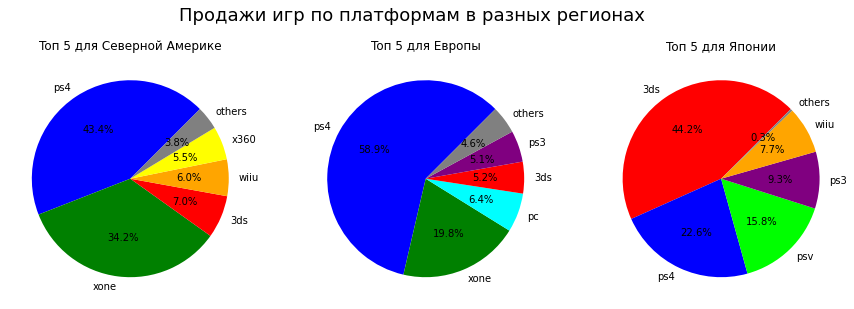

In [54]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Продажи игр по платформам в разных регионах', fontsize=18)

#словарь цветов для категорий платформ
color_dict = {
              'ps4': 'blue',
              'xone': 'green',
              '3ds': 'red',
              'wiiu': 'orange',
              'ps3': 'purple',
              'x360': 'yellow',
              'pc': 'cyan',
              'wii': 'magenta',
              'psv': 'lime',
              'psp': 'pink'
              }

for i, k in enumerate(['na_sales', 'eu_sales', 'jp_sales']):    
    #Построим сводную таблицу топ платформ по продажам по регионам
    sales_top_5 = actual_games_data.pivot_table(
                                                index='platform',
                                                values=k, 
                                                aggfunc='sum'
                                                ).reset_index(#Сбросим индексы, чтобы названия платформ стали столбцом.
                                                     ).sort_values(#Отсортируем по убыванию.
                                                                   by=k,
                                                                   ascending=False
                                                                   ).reset_index(#Снова сбросим индексы, чтобы привести их последовательность в нормальный порядок(0,1,2,3 и т.д)
                                                                                ).drop(#Удалим возникший из-за действия выше столбец с предыдущими индексами.
                                                                                       'index',
                                                                                        axis=1
                                                                                       )
    #Запишем сумму всех продаж строк ниже 10 по индексу включительно в значение столбеца 'total_sales' по этому индексу
    sales_top_5.loc[5, k] = sales_top_5.loc[5, k].sum()
    #Назовём эту строку 'other'
    sales_top_5.loc[5, 'platform'] = 'others'
    #Удалим строки ниже
    sales_top_5 = sales_top_5[0:6]
    #Добавляем на график круговую диаграмму
    axs[i].pie(
               sales_top_5[k], 
               labels=sales_top_5['platform'], 
               autopct='%1.1f%%', 
               startangle=45, 
               colors=[color_dict.get(genre, 'gray') for genre in sales_top_5['platform']]
                )
    if k == 'na_sales':
        region = 'Северной Америке'
    if k == 'eu_sales':
        region = 'Европы'
    if k == 'jp_sales':
        region = 'Японии'
    axs[i].set_title(f'Toп 5 для {region}', fontsize=12)

##### Выводы:
- Соотношения продаж в регионах Северной Америки и Европе хоть и схожи, но имеет ряд отличий:
   - В обоих регионах наиболее популярная платформа ps4, но с разницей в долях продаж, - в Европе она больше более чем на 10 процентов.
   - Вторым местом по популярности в обоих регионах идёт платформа: XOne, - но опять-же с разницей в долях продаж, в Европе её доля меньше, практически вдвое, относительно доли в Америке.
   - Далее уже начинаются более существенные различия:
      - В Европе следующим местом по популярности идёт pc, в америке эта платформа в топ даже не входит.
      - В америки третье место занимает 3ds, в Европе эта платформа имеет четвертое место популярности.
      - Оставшиеся два места в Америки занимают WiiU и X360 - в Европе не входят в топ.
      - Пятое место в Европе занимает ps3 - В Америке не входит в топ.
- Япония значительно отличается от обоих рынков:
   - Самой популярной платформой является 3ds с долей около 45% - на западе и в Европе, доля этой платформы была от 5 до 7%.
   - Вторым место идёт ps4, здесь есть некая схожесть с регионами Европы и Америки - там эта наиболее популярная платформа, - впринципе в этом вопросе все регионе схожы, - на всех трёх рынках эта платформа является одной из наиболее популярных.
   - Третье место в японии занимает платформа PSV - отсутствующая в топе среди остальных регионов.
   - Далее идёт PS3 - четвертое место, доля около 9 процентов, - видимо PlayStation в целом импонирует всем регионам.
   - Последнее место - WiiU - схожая с Северной Америкой ситуация, - там эта платформа занимает четвертое место.

#### Оценим влияние рейтинга ESRB на продажи.

ESRB (Entertainment Software Rating Board) - это организация, ответственная за назначение рейтингов возрастной категории для видеоигр и другого развлекательного программного обеспечения в Северной Америке. Она была создана в 1994 году и является независимой и некоммерческой. Цель ESRB - предоставлять родителям информацию о содержании игр и помогать им принимать осознанные решения о том, подходит ли игра для их детей.

ESRB присваивает играм определенные рейтинги, которые указывают на целевую аудиторию по возрасту. Рейтинги включают в себя категории, такие как "Для всех", "Для подростков", "Для взрослых", и другие. Эти рейтинги помогают потребителям определить, соответствует ли содержание игры возрасту и интересам их детей, и сделать обоснованный выбор при покупке или прокате игр.

In [55]:
#Верем назад tbd для категорий без рейтинга
actual_games_data.loc[actual_games_data['rating'].isna(), 'rating'] = 'tbd'
#Выведем список уникальных значений столбца rating.
print('Список рейтингов ESRB столбца "rating":')
print(actual_games_data['rating'].unique())

Список рейтингов ESRB столбца "rating":
['tbd' 'e' 'm' 't' 'e10+']


/opt/conda/lib/python3.9/site-packages/pandas/core/indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)


##### Описание:
- E (Everyone) - Для всех: Игры с этим рейтингом подходят для всех возрастов. Они могут содержать минимальное насилие и простой или немногосложный контент, подходящий для всех возрастов.
- E10+ (Everyone 10 and older) - Для всех от 10 лет и старше: Игры с этим рейтингом могут содержать незначительное насилие, немного больше мультипликационного или комического насилия, или несколько мягких материалов, но в целом подходят для детей от 10 лет и старше.
- T (Teen) - Подросткам 13+: Эти игры могут содержать насилие, непристойные сцены, грубый юмор, минимальное использование крови, легкий намёк на сексуальность и/или частое непристойное использование языка.
- M (Mature) - Для взрослых 17+: Игры с этим рейтингом могут содержать интенсивное насилие, кровь и кишки, сексуальный контент и/или сильный язык, что делает их неподходящими для детей.

In [56]:
#Построим сводную таблицу с общим количеством продаж агрегированную по рейтингу ESRB и региону.
pivot_table_esrb = actual_games_data.pivot_table(
                                          index='rating', 
                                          values=('na_sales', 'eu_sales', 'jp_sales'), 
                                          aggfunc='sum'
                                          ).reset_index()

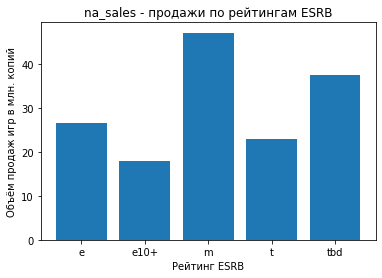

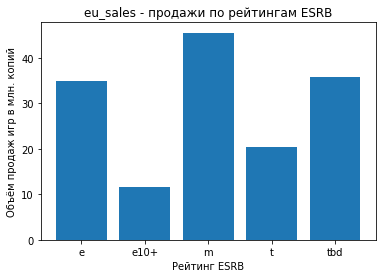

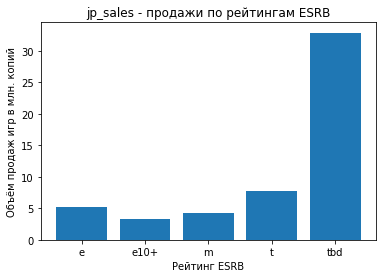

In [57]:
#С помощью цикла for построим гистограммы распределения продаж по рейтингу для всех регионов.
for k in ['na_sales', 'eu_sales', 'jp_sales']:
    plt.bar(
            range(len(pivot_table_esrb.index)), 
            pivot_table_esrb[k], 
            label=pivot_table_esrb['rating'], 
            tick_label=pivot_table_esrb['rating'],
            )
    plt.xlabel('Рейтинг ESRB')
    plt.ylabel('Объём продаж игр в млн. копий')
    plt.title(f'{k} - продажи по рейтингам ESRB')
    plt.show()

##### Вывод: 
- Распределение продаж в Европе и Америки практически идентично, наибольшие продажи у игр с рейтингом M - обозначающим, что игра предназначена для взрослой аудитории. Это логично ведь эти игры имеют ряд отличий от всех других:
   - Широкий спрос: Взрослая аудитория часто более активно приобретает игры, поскольку они могут быть более заинтересованы в более взрослых и содержательных темах, которые могут присутствовать в играх с рейтингом M.
   - Качество контента: Игры с рейтингом M могут предлагать более глубокий сюжет, сложные персонажи и более высокое качество геймплея, что привлекает больше игроков.
   - Больший бюджет на маркетинг: Крупные издатели могут вкладывать больше средств в маркетинг и рекламу игр с рейтингом M, что может привести к большему числу продаж.
   - Брендирование и репутация: Некоторые серии игр становятся известными своими взрослыми темами и содержанием, и в результате приобретают большую популярность среди взрослых игроков.
   - Социокультурные факторы: Взрослые игроки могут иметь больше свободного времени и денег для того, чтобы потратить на игры, по сравнению с более молодыми игроками.
 - В Японии распределение выглядит соверешённо иначе, наибольшее количество продаж без рейтинга ESRB в категории tbd - обозначающий отсутствие рейтинга, видимо в японии более популярные игры ориентированные на местный рынок или отличные ориентаентации на западные рынки(не ориентированные на рынки Америки и Европы игры без рейтинга ESRB). Это можно объяснить следующими факторами:
   - Предпочтения пользователей: Японские геймеры имеют свои уникальные предпочтения в играх, которые могут отличаться от западных рынков. Это может включать в себя жанры, сюжеты и игровой стиль.
   - Местные разработчики: В Японии существует множество местных разработчиков игр, которые могут создавать контент, ориентированный преимущественно на внутренний рынок, и не всегда представлять свои игры на мировой арене.
   - Различия в культуре: Различия в культуре могут привести к появлению игр, которые не имеют широкой популярности за пределами Японии, и, следовательно, не получают рейтинга ESRB.
   - Система рейтингов: Япония имеет свою собственную систему рейтингов для видеоигр, называемую CERO (Computer Entertainment Rating Organization). Некоторые игры могут получить рейтинг от CERO, но не иметь рейтинга ESRB.
   - Отличия в маркетинге: Компании, выпускающие игры, могут придавать разное значение получению рейтинга ESRB в зависимости от их рыночной стратегии и целевой аудитории.

### Шаг 5. Проверка гипотез.

In [58]:
#Избавимся от заглушек перед проверкой гипотез.
#Преобразуем тип
actual_games_data.loc[:,'user_score'] = actual_games_data['user_score'].astype(float)
#Избавимся от нулей или NaN
actual_games_data = actual_games_data.dropna(subset=['user_score'])
actual_games_data = actual_games_data.query('user_score != 0')

/opt/conda/lib/python3.9/site-packages/pandas/core/indexing.py:1676: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(ilocs[0], value, pi)


##### Аргументироем выбор aplha:
- Обычно наиболее распространённые уровни значимости в статистических исследованиях - это 0.05 (5%) и 0.01 (1%).

- Однако конкретный выбор зависит от контекста и требований к исследованию:

  - Уровень значимости 0.05 является наиболее распространённым и часто используется в различных областях научных исследований, таких как социология, психология, экономика и другие.
  - Уровень значимости 0.01 и ниже обычно выбирается в случае, когда требуется более высокая степень уверенности в полученных результатах, например: 
     - Контекст задачи: В некоторых областях, например таких как физика элементарных частиц, требуется намного более высокий уровень доверия, например, 0.0000003 (0.00003%).
     - Cтепень риска ошибки: Уровень значимости определяет вероятность совершения ошибки первого рода (ложноположительного результата) при отклонении нулевой гипотезы, когда она на самом деле верна. Чем ниже уровень значимости, тем меньше вероятность такой ошибки. Однако уменьшение уровня значимости также увеличивает вероятность совершения ошибки второго рода (ложноотрицательного результата).
       - Требования к достоверности результатов: В некоторых случаях может быть критически важно минимизировать вероятность ошибки, например, в клинических испытаниях нового лекарства. В таких случаях можно выбрать более низкий уровень значимости, например, 0.01 или даже 0.001.
     - Размер выборки и ожидаемый эффект: Величина выборки и ожидаемый размер эффекта могут влиять на подбор уровня значимости. Большие выборки могут обнаруживать более мелкие эффекты при том же уровне значимости.
     
- В нашем случае достаточно будет базового уровня - Alpha 0.5, да и размер нашей выборки, не настолько большой, чтобы обнаруживать мелкие эффекты, а относительно контекста задача - этого и не требуется.

##### 5.1 Гипотеза о равенстве средних пользовательских рейтингов для Xbox One и PC:
- Нулевая гипотеза (H0): Средние пользовательские рейтинги платформ Xbox One и PC равны.
- Альтернативная гипотеза (H1): Средние пользовательские рейтинги платформ Xbox One и PC различаются.

In [59]:
#Проведем t-тест.
alpha = 0.05 #уровень значимости
results_one = st.ttest_ind(
                           actual_games_data.query('platform == "pc"')['user_score'], 
                           actual_games_data.query('platform == "xone"')['user_score'], 
                           alternative='two-sided'
                           )
#Выведем значение pvalue
print('p-значение:', results_one.pvalue)

#Выводим вывод
if results_one.pvalue < alpha: 
    print('Отвергаем нулевую гипотезу, в пользу альтернативной')
else:
    print('Не получилось отвергнуть нулевую гипотезу');

p-значение: 0.2778542084733835
Не получилось отвергнуть нулевую гипотезу


##### Вывод:
- На основании проведенного теста на равенство средних пользовательских рейтингов для платформ Xbox One и PC с уровнем значимости 0.05, было получено значение p-значения равное примерно 0.27.
- Это не позволило отвергнуть нулевую гипотезу - о равенстве средних пользовательских рейтингов платформ Xbox One и PC - мы обнаружили статистически значимые схожести среднего значения между средними пользовательскими рейтингами для платформ Xbox One и PC. 

##### Вывод:
- На основании теста на равенство средних пользовательских рейтингов для платформ Xbox One и PC с уровнем значимости 0.05, мы не обнаружили статистически значимых различий между ними (p-значение ≈ 0.27). Это позволяет нам не отвергать нулевую гипотезу о равенстве средних пользовательских рейтингов на обеих платформах. Таким образом, результаты указывают на схожесть пользовательских оценок и вероятно восприятия игр на Xbox One и PC. Это наблюдение может быть полезным для принятия решений в индустрии видеоигр, подчеркивая, что игровой опыт, вероятно, не зависит от выбора платформы.

In [60]:
# Приведены два датасета: сумма покупок, совершённых за месяц посетителями ...

sample_1 = [3071, 3636, 3454, 3151, 2185, 3259, 1727, 2263, 2015,
2582, 4815, 633, 3186, 887, 2028, 3589, 2564, 1422, 1785,
3180, 1770, 2716, 2546, 1848, 4644, 3134, 475, 2686,
1838, 3352]
sample_2 = [1211, 1228, 2157, 3699, 600, 1898, 1688, 1420, 5048, 3007,
509, 3777, 5583, 3949, 121, 1674, 4300, 1338, 3066,
3562, 1010, 2311, 462, 863, 2021, 528, 1849, 255,
1740, 2596]
alpha = .05 # критический уровень статистической значимости
# если p-value окажется меньше него - отвергнем гипотезу
results = st.ttest_ind(
sample_1,
sample_2)
print('p-значение:', results.pvalue)
if (results.pvalue < alpha):
    print("Отвергаем нулевую гипотезу")
else:
    print("Не получилось отвергнуть нулевую гипотезу")

p-значение: 0.1912450522572209
Не получилось отвергнуть нулевую гипотезу


##### 5.2 Гипотеза о различии средних пользовательских рейтингов для жанров Action и Sports:
- Нулевая гипотеза (H0): Средние пользовательские рейтинги жанров Action и Sports равны.
- Альтернативная гипотеза (H1): Средние пользовательские рейтинги жанров Action и Sports различаются.

In [61]:
#Проведем t-тест.
alpha = 0.05 #уровень значимости
results_one = st.ttest_ind(
                           actual_games_data.query('genre == "action"')['user_score'], 
                           actual_games_data.query('genre == "sports"')['user_score'], 
                           alternative='two-sided'
                           )
#Выведем значение pvalue
print('p-значение:', results_one.pvalue)

#Выводим вывод
if results_one.pvalue < alpha: 
    print('Отвергаем нулевую гипотезу, в пользу альтернативной')
else:
    print('Не получилось отвергнуть нулевую гипотезу');

p-значение: 1.0012846807938657e-13
Отвергаем нулевую гипотезу, в пользу альтернативной


#### Вывод:
- На основании проведенного теста на равенство средних пользовательских рейтингов для жанров action и sports с уровнем значимости 0.05, было получено значение p-значения равное около 0.0000000000001.
- Нулевая гипотеза была отвергнута в пользу альтернативной - о различие средних пользовательских рейтингов для жанров action и sports - мы не обнаружили статистически значимых схожестей взаимосвязей среднего значения между средними пользовательскими рейтингами для жанров action и sports.

### Шаг 6. Общий вывод.

### Step 6. Overall Conclusion.

#### Было проведено исследование данных компьютерных игр. Задача звучала так:
- Выявить факторы, определяющие закономерности успешности игр, которые могут помочь бизнесу — интернет-магазину «Стримчик» — прогнозировать успешные продукты и планировать рекламные кампании.

#### Исследование было выполнено в 6 этапов:
1. На первом этапе данные были загружены и сохранены в переменную, после чего была изучена и описана их общая структура.
2. На втором этапе была проведена предобработка данных: названия столбцов приведены к единому регистру, исправлены типы данных, обработаны пропуски, а также создан столбец с суммарными продажами по всем регионам.
3. На третьем этапе был выполнен исследовательский анализ данных, в ходе которого определён актуальный период для анализа и дальнейшего прогнозирования.
4. На четвёртом этапе был составлен портрет пользователя по регионам (NA, EU, JP):
   - определены топ-5 платформ;
   - определены топ-5 жанров;
   - оценено влияние рейтинга ESRB на продажи.
5. На пятом этапе были проверены гипотезы:
   - равенство средних пользовательских рейтингов платформ Xbox One и PC;
   - различие средних пользовательских рейтингов жанров Action и Sports.
6. На шестом этапе был сформулирован общий вывод.

#### Итоговые выводы для бизнеса:
- Наиболее актуальные платформы:
   - PS4  
   - Xbox One  
   - 3DS (для рынка Японии)

- Наиболее популярные жанры:
   - Для Северной Америки и Европы (около 90% продаж):
     1. Shooter  
     2. Action  
     3. Sports  
     4. Role-Playing  
     5. Misc / Racing  

   - Для Японии (около 90% продаж):
     1. Action  
     2. Role-Playing  
     3. Shooter  
     4. Misc  
     5. Adventure  

- Влияние рейтингов:
   - Оценки критиков сильнее влияют на продажи, чем оценки пользователей, однако ни те, ни другие не дают достаточно точного прогноза. Использовать их как основной инструмент прогнозирования рискованно.
   - Влияние рейтингов примерно одинаково для разных платформ.

- Влияние ESRB рейтинга:
   - В Европе и Северной Америке наибольшие продажи имеют игры с рейтингом **M (Mature)**.
   - В Японии значительная часть игр не имеет рейтинга ESRB. Среди тех, у которых рейтинг есть, наиболее успешны игры с рейтингами **T (Teen)** и **E (Everyone)**.

---

#### A study of video game data was conducted. The task was:
- To identify the factors that determine game success and help the business — the online store “Streamchik” — predict successful products and plan marketing campaigns.

#### The study was carried out in 6 stages:
1. Data were loaded and explored to understand their structure.
2. Data preprocessing was performed: column names were standardized, data types were corrected, missing values were handled, and a total sales column was created.
3. Exploratory data analysis was conducted, including identifying a relevant time period for analysis and forecasting.
4. A user profile was created for each region (NA, EU, JP):
   - top-5 platforms were identified;
   - top-5 genres were identified;
   - the impact of ESRB ratings on sales was analyzed.
5. Hypothesis testing was performed:
   - equality of average user ratings for Xbox One and PC;
   - difference in average user ratings between Action and Sports genres.
6. A final conclusion was drawn.

#### Key business insights:
- Most relevant platforms:
   - PS4  
   - Xbox One  
   - 3DS (for the Japanese market)

- Most popular genres:
   - In North America and Europe (≈90% of sales):
     - Shooter, Action, Sports, Role-Playing, Misc/Racing  

   - In Japan (≈90% of sales):
     - Action, Role-Playing, Shooter, Misc, Adventure  

- Ratings impact:
   - Critic scores have a stronger influence on sales than user scores, but neither provides reliable predictive power on its own.
   - The influence of ratings is consistent across platforms.

- ESRB rating impact:
   - In Europe and North America, games rated **M (Mature)** generate the highest sales.
   - In Japan, many games do not have ESRB ratings; among rated games, **T (Teen)** and **E (Everyone)** perform best.

### Бонус / Additional Task

In [62]:
data_games = pd.read_csv('/datasets/games.csv')

In [63]:
data_games.columns = map(str.lower, data_games.columns)

In [64]:
data_games = data_games.dropna(subset = ['year_of_release', 'name', 'genre'])

In [65]:
data_games['user_score'] = data_games['user_score'].replace('tbd', np.nan).astype('float')

In [66]:
data_games['rating'] = data_games['rating'].fillna('unknown')

In [67]:
data_games['total_sales'] = data_games[['na_sales','eu_sales','jp_sales', 'other_sales']].sum(axis = 1)

In [68]:
# check
# круги + категория другие

# функция не работает на версии библиотеки pandas = 2.0 (метод .append устарел)

def graph (df, year, region, name, axes):
    
    df = df.query('year_of_release >= @year')
    
    sales = df.pivot_table(index='platform', 
                           values=region, 
                           aggfunc='sum').nlargest(5, region)
    
    sales = sales.reset_index()
    
    sales = (
            sales.append({'platform': 'Other', region: df[region].sum() 
                       - sales[region].sum()}, ignore_index= True)
         )
    
    
    sales.columns = ['platform', 'sales']
      
# Цветовая гамма не подбиралась специально под платформы, кому-что попадется, 😉      
      
    labels_c=sales.platform
    colours = {'Wii':'C60', 'NES':'C1', 'GB':'C2', 'DS':'C3', 'X360':'C4', 
    'PS3':'C5', 'PS2':'C6', 'SNES':'C7', 'GBA':'C8',
               'PS4':'lightsteelblue', '3DS':'orange', 
               'N64':'C11', 'PS':'C12', 'XB':'C13', 'PC':'Fuchsia', '2600':'C15', 'PSP':'C48', 
               'XOne':'LimeGreen',
               'WiiU':'C18', 'GC':'C19', 'GEN':'C20', 'DC':'C21', 'PSV':'C22', 
               'SAT':'C23', 'SCD':'C24', 'WS':'C25', 'NG':'C26', 
               'TG16':'C27', '3DO':'C28', 'GG':'C29', 'PCFX':'C30', 'Other':'darkred'}
   
    sales.plot(kind='pie',
               y="sales",
               
               autopct='%1.0f%%',
               wedgeprops={'linewidth': 3.0, 'edgecolor': 'white'},
               textprops={'size': 'x-large'}, 
               labels= labels_c,
               colors=[colours[key] for key in labels_c],
               legend=False, 
               title = f"Популярность платформ в {name} ", 
               ax = axes).set(ylabel='')
    
    plt.tight_layout()

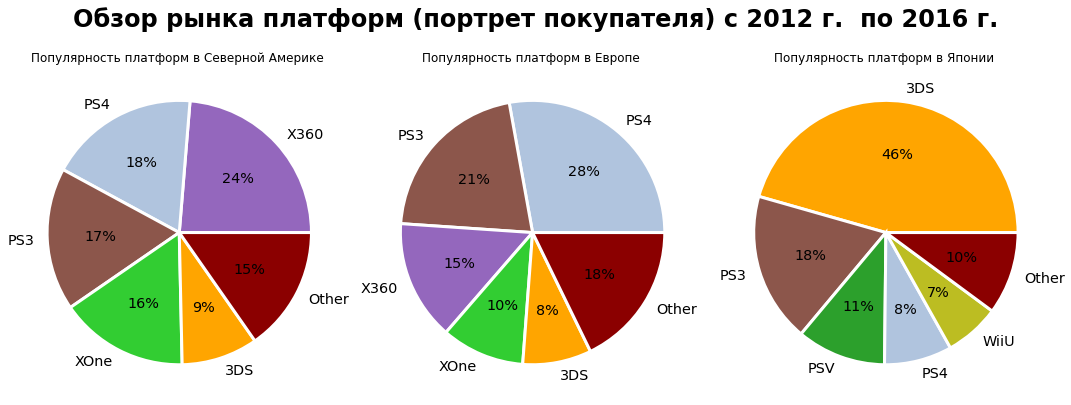

In [69]:
# check
# круги в ряд

x_year = 2012

fig, axes = plt.subplots(1, 3, figsize = (15,6))
fig.suptitle(f'Обзор рынка платформ (портрет покупателя) с {x_year} г.  по 2016 г.', fontsize = 24, fontweight='bold')

graph(data_games, x_year, 'na_sales', 'Северной Америке', axes[0])
graph(data_games, x_year,'eu_sales', 'Европе', axes[1])
graph(data_games, x_year, 'jp_sales', 'Японии', axes[2])

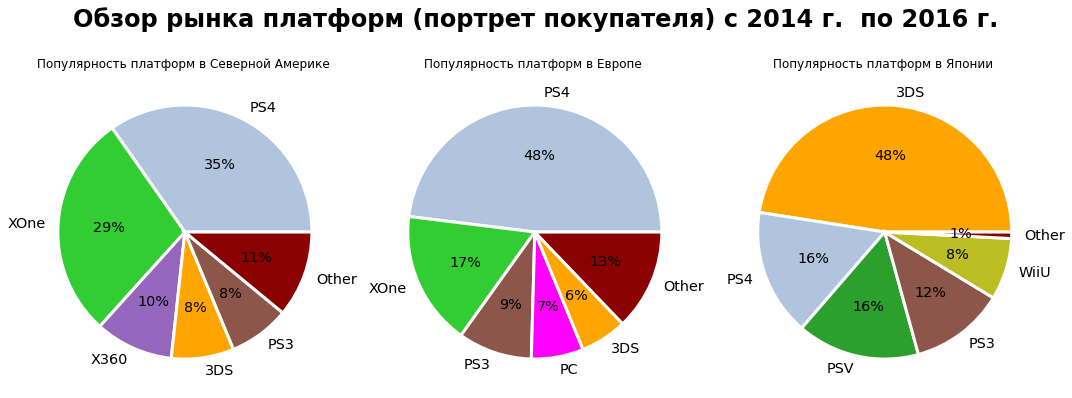

In [70]:
# check
# круги в ряд

x_year = 2014

fig, axes = plt.subplots(1, 3, figsize = (15,6))
fig.suptitle(f'Обзор рынка платформ (портрет покупателя) с {x_year} г.  по 2016 г.', fontsize = 24, fontweight='bold')

graph(data_games, x_year, 'na_sales', 'Северной Америке', axes[0])
graph(data_games, x_year,'eu_sales', 'Европе', axes[1])
graph(data_games, x_year, 'jp_sales', 'Японии', axes[2])

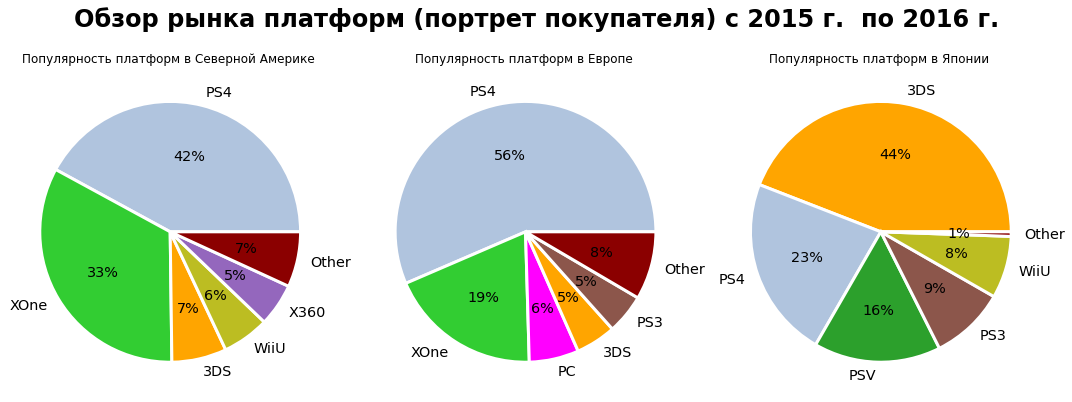

In [71]:
# check
# круги в ряд

x_year = 2015

fig, axes = plt.subplots(1, 3, figsize = (15,6))
fig.suptitle(f'Обзор рынка платформ (портрет покупателя) с {x_year} г.  по 2016 г.', fontsize = 24, fontweight='bold')

graph(data_games, x_year, 'na_sales', 'Северной Америке', axes[0])
graph(data_games, x_year,'eu_sales', 'Европе', axes[1])
graph(data_games, x_year, 'jp_sales', 'Японии', axes[2])